# Final Project

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

### Packages

In [ ]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)
library(forecast)
library(zoo)
library(ggplot2)
library(tidyr)
library(parallel)

### 0. Data Preparation

In [2]:
data <- load("data_project/26.RData")   # loads the .RData file into the environment
head(data)                               # shows the name of object stored in the file
asset_data <- get(data[1])              # retrieves the first object by name
head(asset_data)                        

[1] "amat"

                    ret         RV        RV_p        RV_n          RS       RK
2010-01-05  0.010600358 0.01537440 0.010802724 0.010939525  0.22027109 4.607369
2010-01-06 -0.002112787 0.01482381 0.011268814 0.009631161  0.58156996 3.443174
2010-01-07 -0.004239012 0.01455766 0.009431595 0.011089210 -0.53822008 4.062540
2010-01-08  0.006351798 0.01627584 0.012371915 0.010575383  0.02566745 4.681865
2010-01-11  0.041973644 0.02193678 0.013281618 0.017459120 -1.15919678 5.918139
2010-01-12 -0.006089911 0.02460140 0.014433799 0.019922207 -0.60888995 3.864707

"amat" is the ticker symbol for Applied Materials, Inc. (AMAT) - a large US semiconductor equipment company traded on NASDAQ.

### 0. Data Quality Checks

Before we start estimating our models, we need to check for data quality issues that could potentially break our models. We check for four conditions: missing values (NAs) in returns, missing values in Realised Volatility (RV), exact zero returns, and non-positive RV values. Missing data fundamentally disrupts time-series continuity, breaking both OLS and Maximum Likelihood (MLE) estimators. Exact zero returns flatten the optimization gradient, potentially causing the GARCH Hessian matrix to fail inversion. Lastly, zero or negative RV values trigger mathematically undefined logarithmic operations within the realGARCH measurement equation.

In [3]:
# --- Initial Checks ---
cat("Missing in Returns:", sum(is.na(asset_data$ret)), "\n")
cat("Missing in RV:", sum(is.na(asset_data$RV)), "\n")

zero_rows <- which(asset_data$ret == 0)
bad_rv <- sum(asset_data$RV <= 0, na.rm = TRUE)

cat("Zero Returns:", length(zero_rows), "\n")
cat("Zero/Negative RV:", bad_rv, "\n\n")

Missing in Returns: 0 
Missing in RV: 0 


Zero Returns: 16 
Zero/Negative RV: 0 



We find that the only defect present are 16 instances of zero returns. While inter-day returns certainly can take on zero values (US equity prices have a minimum tick size of $0.01), we need to deal with them somehow, since they could potentially cause our GARCH models - estimated via MLE - to fail to converge. Let us now print short intervals around these zero values to investigate the origin of these zero values.

In [4]:
# --- Print Zero Windows ---
if (length(zero_rows) > 0) {
    for (i in 1:length(zero_rows)) {
        row_idx <- zero_rows[i]
        start_idx <- max(1, row_idx - 2)
        end_idx <- min(nrow(asset_data), row_idx + 2)
        
        cat("Window:", as.character(index(asset_data)[row_idx]), "\n")
        print(asset_data[start_idx:end_idx, c("ret", "RV")])
        cat("\n")
    }
}

Window: 2010-10-14 
                    ret         RV
2010-10-12  0.017055159 0.01641553
2010-10-13  0.014271636 0.01649048
2010-10-14  0.000000000 0.01552123
2010-10-15  0.004159068 0.01717744
2010-10-18 -0.005827551 0.01352247

Window: 2010-12-30 
                     ret          RV
2010-12-28  0.0071535977 0.006264003
2010-12-29  0.0085272414 0.007729041
2010-12-30  0.0000000000 0.006438096
2010-12-31 -0.0007119736 0.009558380
2011-01-03  0.0000000000 0.013812577

Window: 2011-01-03 
                     ret          RV
2010-12-30  0.0000000000 0.006438096
2010-12-31 -0.0007119736 0.009558380
2011-01-03  0.0000000000 0.013812577
2011-01-04 -0.0049647671 0.010664788
2011-01-05 -0.0164897688 0.010349553

Window: 2011-06-30 
                   ret         RV
2011-06-28 0.023111368 0.01328752
2011-06-29 0.003153168 0.01252186
2011-06-30 0.000000000 0.01263422
2011-07-01 0.022518956 0.01556065
2011-07-05 0.022031703 0.01243611

Window: 2011-10-18 
                    ret         RV
201

Examining the windows around our zero values, we can see that even though the return is zero, RV takes on non-zero values. This indicates that trading occured on the zero-return days and the price just came back to the value at the start of the day. This means that we cannot omit these observations, as they are fully valid data points. Therefore, we opt to add a microscopic constant ($10^{-6}$) to the zero returns. This resolves the MLE convergence failure without empirically biasing the parameter estimates.

In [5]:
# --- Apply Fixes ---
if (length(zero_rows) > 0) {
    asset_data$ret[asset_data$ret == 0] <- 1e-6
}


## 1. Data description

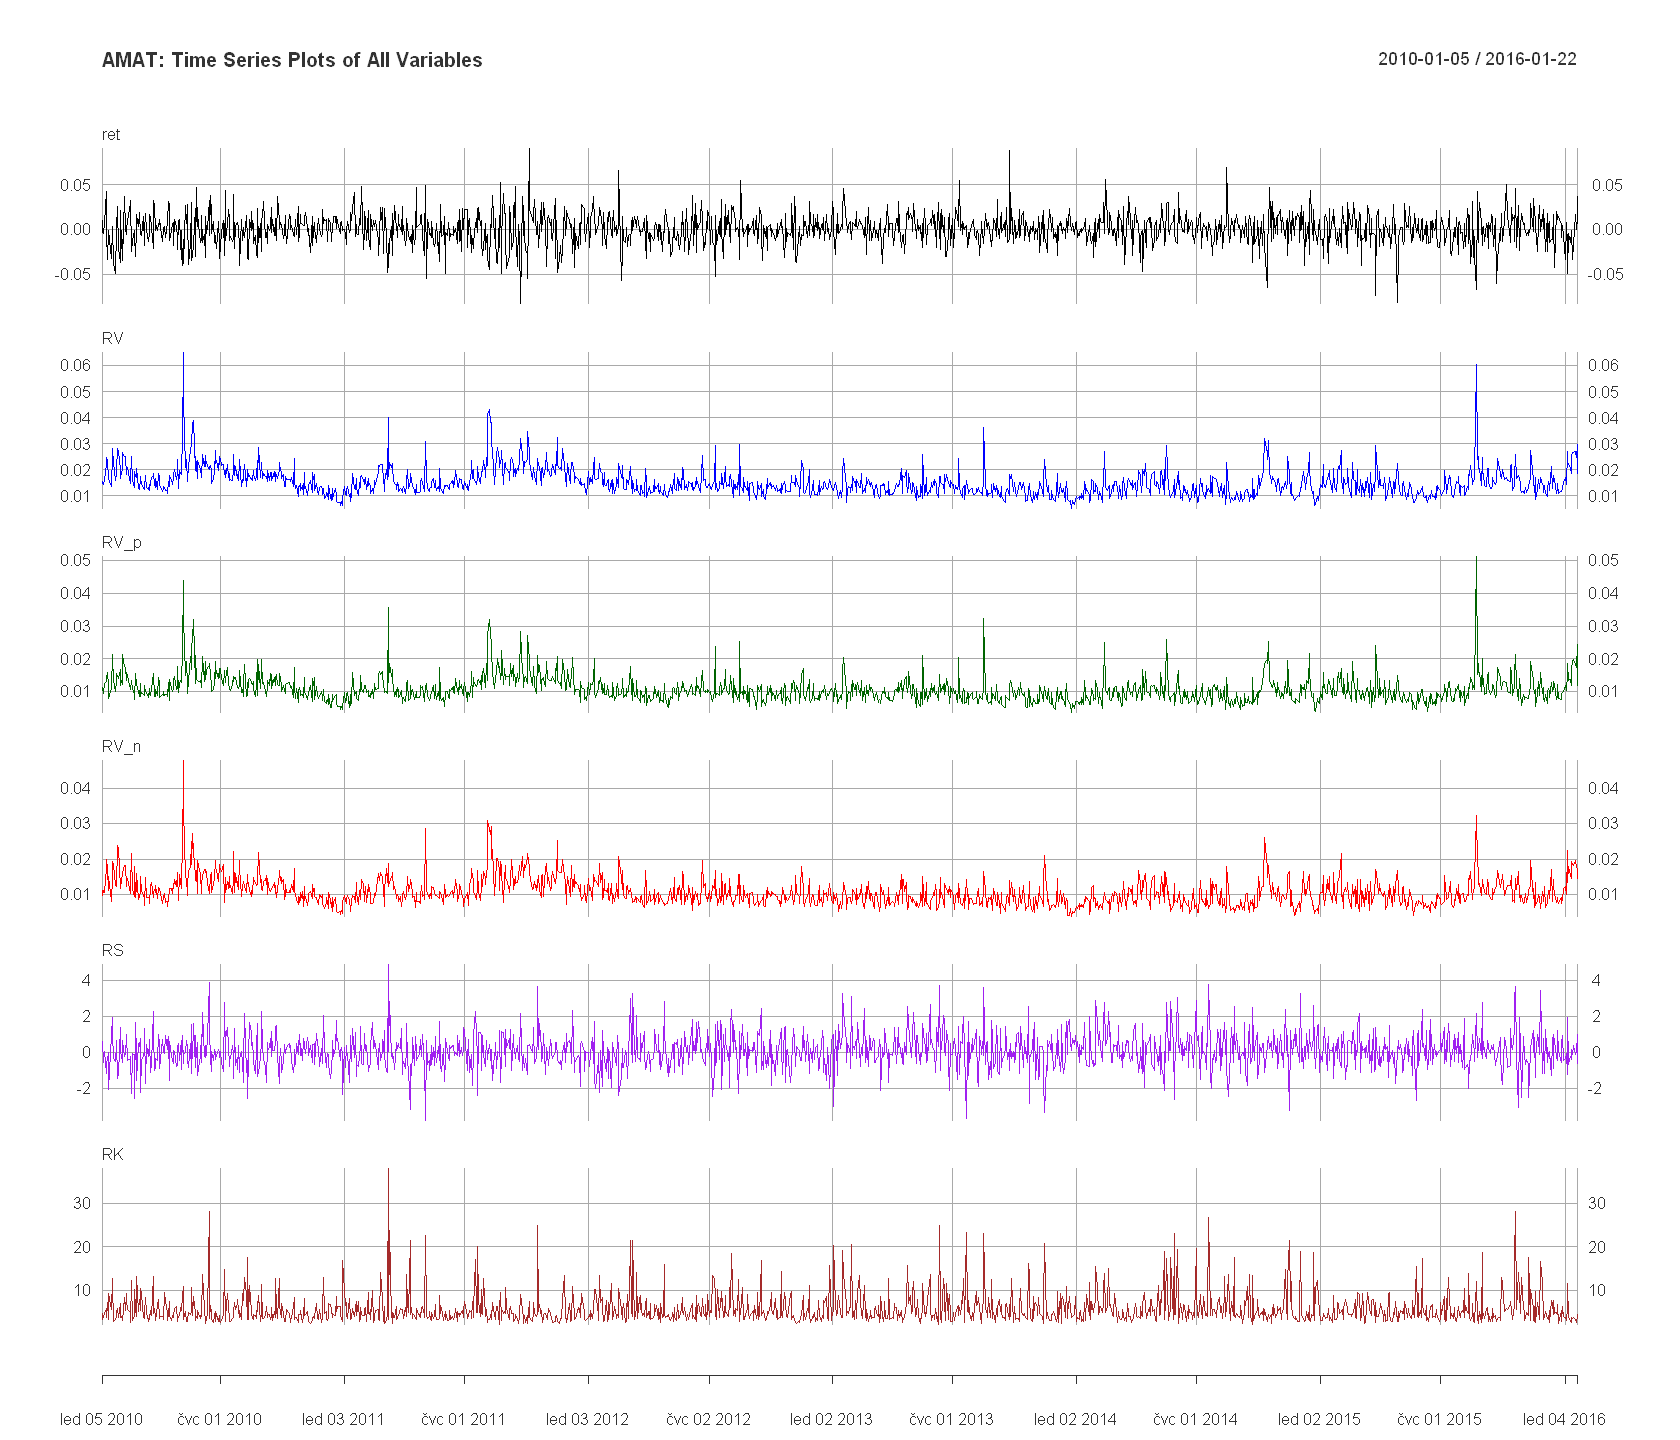

In [6]:
options(repr.plot.width = 14, repr.plot.height = 12)
plot.xts(asset_data, 
         multi.panel = TRUE, 
         yaxis.same = FALSE,
         col = c("black", "blue", "darkgreen", "red", "purple", "brown"),
         lwd = 0.8,
         main = "AMAT: Time Series Plots of All Variables")

In [7]:
# descriptive statistics
summary(coredata(asset_data)) # view the summary of all columns except the index column

      ret                   RV                RV_p               RV_n         
 Min.   :-0.0831897   Min.   :0.005378   Min.   :0.003804   Min.   :0.003802  
 1st Qu.:-0.0096931   1st Qu.:0.011861   1st Qu.:0.008198   1st Qu.:0.007937  
 Median : 0.0008695   Median :0.014288   Median :0.010081   Median :0.009841  
 Mean   : 0.0002284   Mean   :0.015212   Mean   :0.010768   Mean   :0.010558  
 3rd Qu.: 0.0106051   3rd Qu.:0.017221   3rd Qu.:0.012362   3rd Qu.:0.012405  
 Max.   : 0.0906058   Max.   :0.065073   Max.   :0.051231   Max.   :0.047888  
       RS                 RK        
 Min.   :-3.76626   Min.   : 2.237  
 1st Qu.:-0.48534   1st Qu.: 3.636  
 Median : 0.07282   Median : 4.607  
 Mean   : 0.10153   Mean   : 5.713  
 3rd Qu.: 0.62721   3rd Qu.: 6.383  
 Max.   : 4.86950   Max.   :37.962  

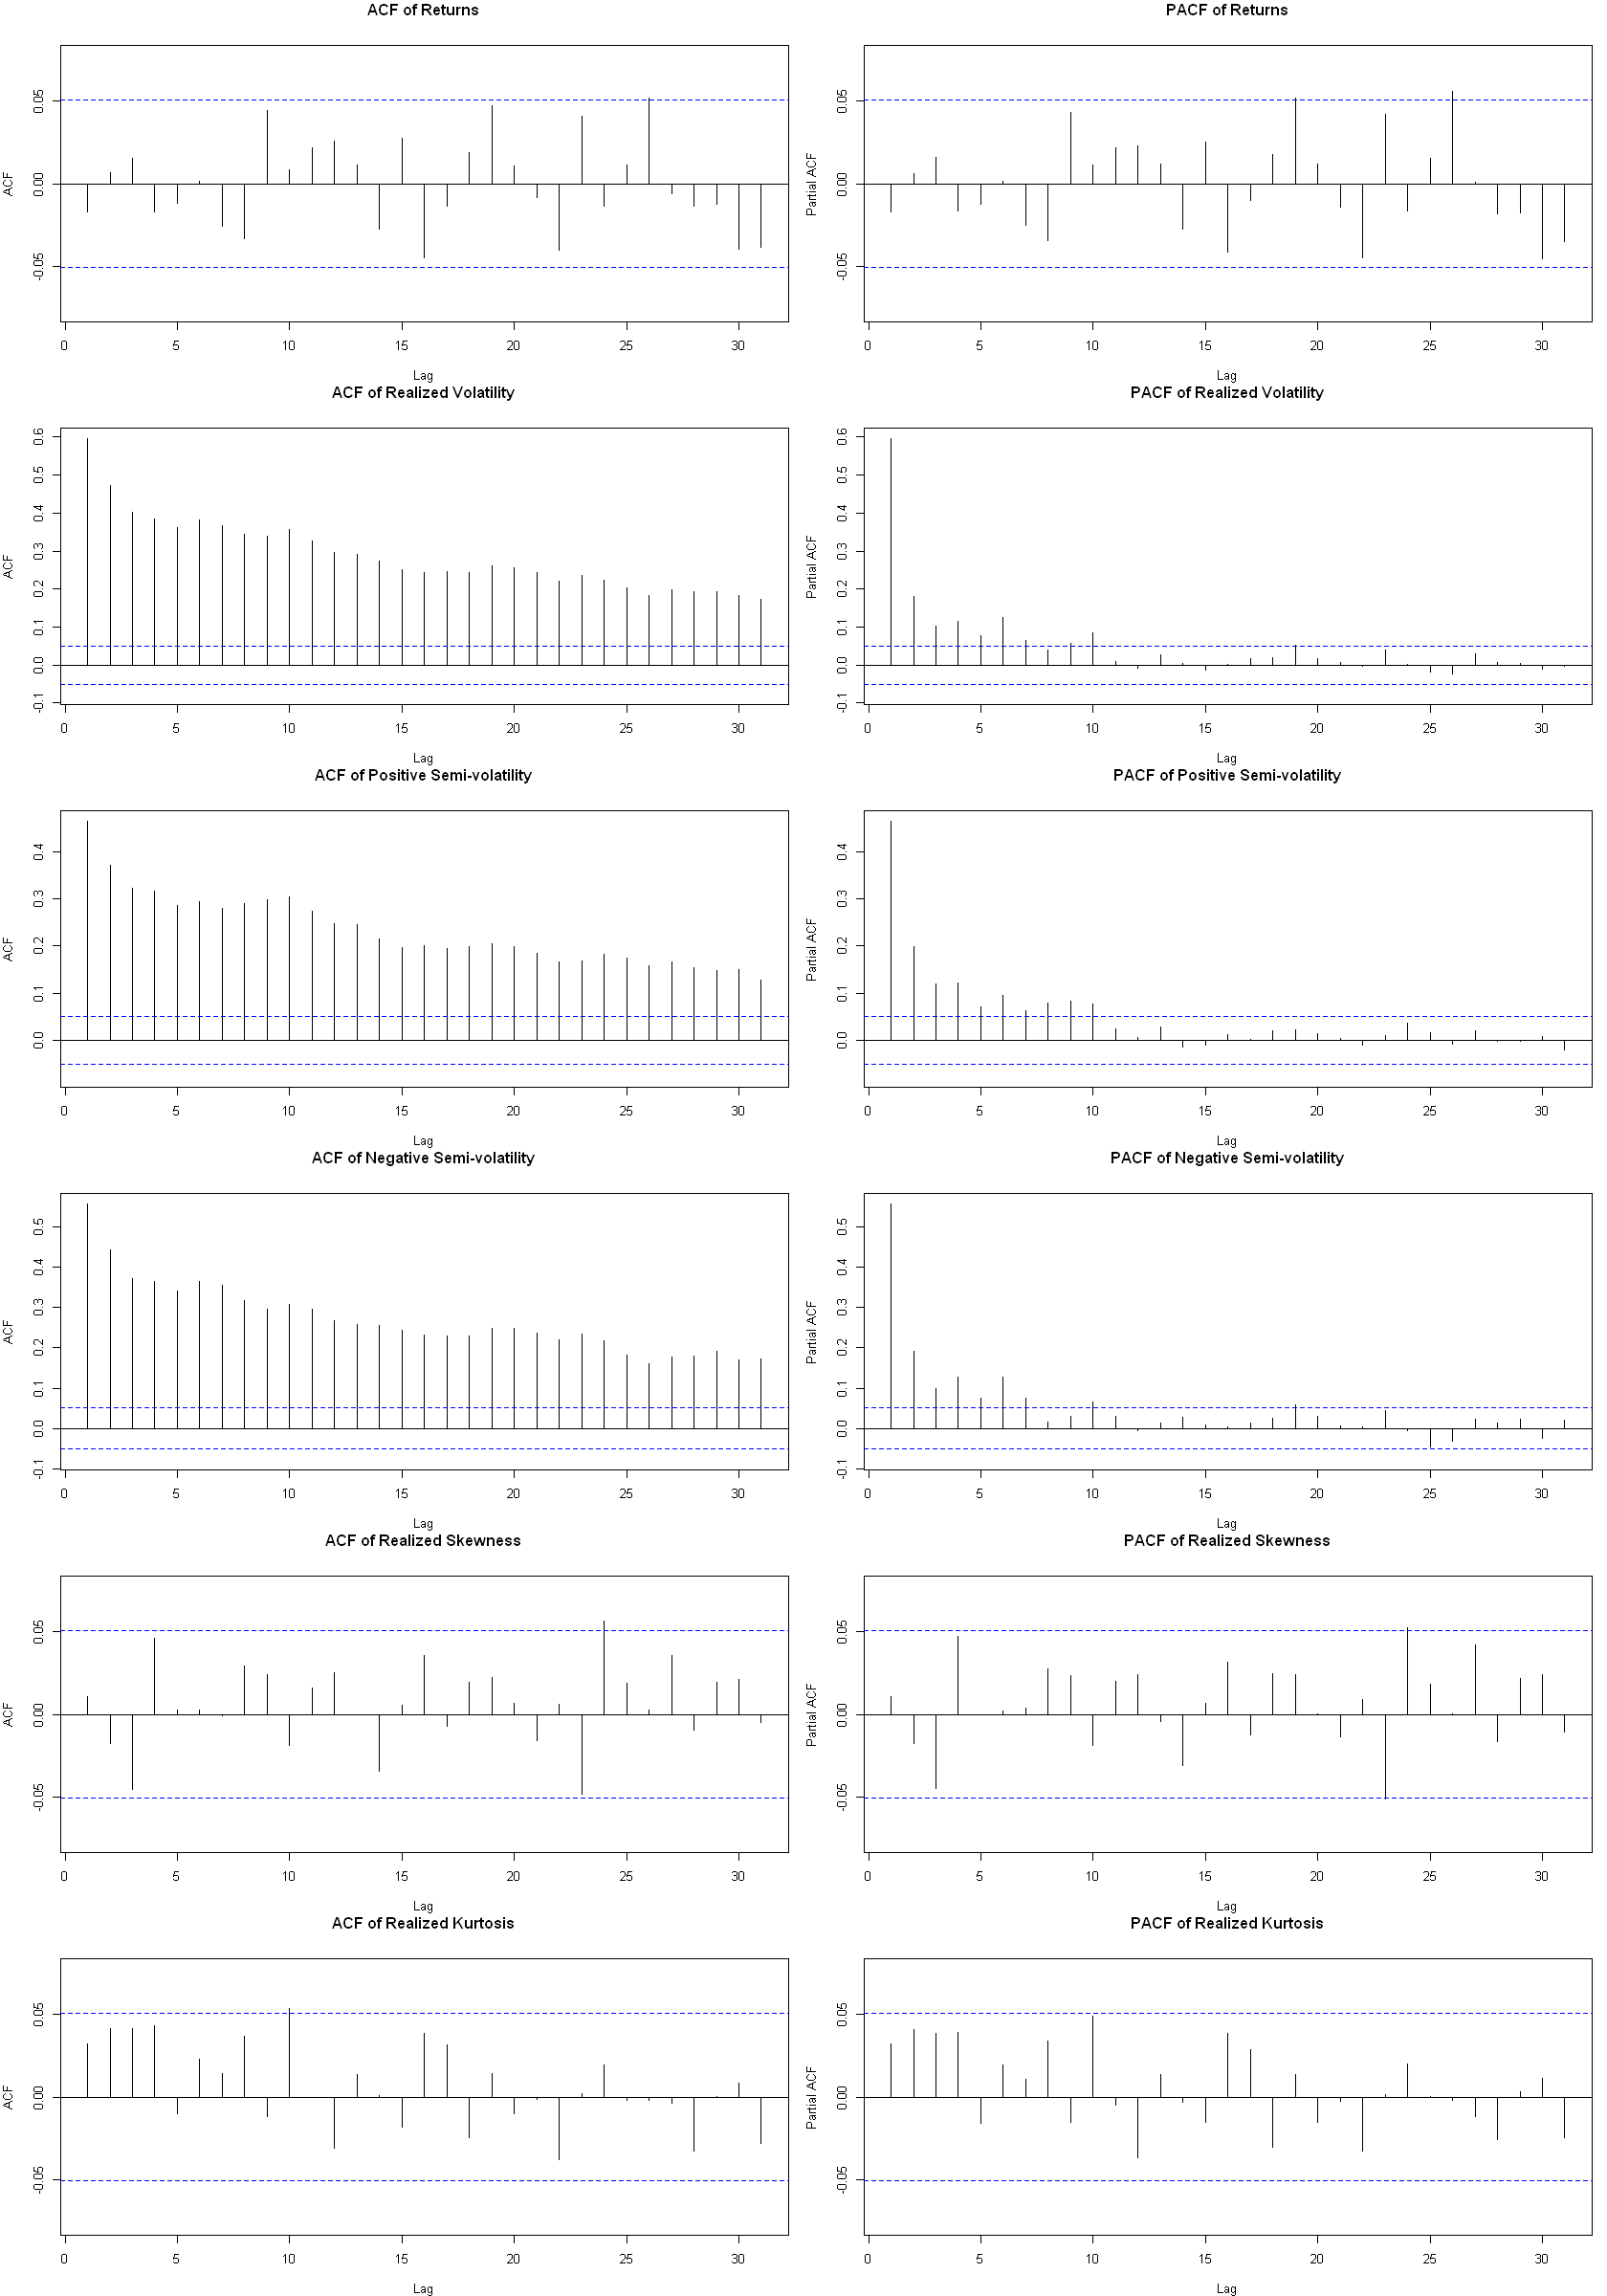

In [8]:
options(repr.plot.width = 14, repr.plot.height = 20)
par(mfrow = c(6, 2), mar = c(4, 4, 3, 1))

#ret
Acf(asset_data$ret, main = "ACF of Returns")
Pacf(asset_data$ret, main = "PACF of Returns")

#rv
Acf(asset_data$RV, main = "ACF of Realized Volatility")
Pacf(asset_data$RV, main = "PACF of Realized Volatility")

#rvp
Acf(asset_data$RV_p, main = "ACF of Positive Semi-volatility")
Pacf(asset_data$RV_p, main = "PACF of Positive Semi-volatility")

#rvn
Acf(asset_data$RV_n, main = "ACF of Negative Semi-volatility")
Pacf(asset_data$RV_n, main = "PACF of Negative Semi-volatility")
#rs
Acf(asset_data$RS, main = "ACF of Realized Skewness")
Pacf(asset_data$RS, main = "PACF of Realized Skewness")
#rk
Acf(asset_data$RK, main = "ACF of Realized Kurtosis")
Pacf(asset_data$RK, main = "PACF of Realized Kurtosis")


par(mfrow = c(1, 1))

The dataset covers 2010-01-05 to 2016-01-22, providing 1 500 daily observations for AMAT. Each observation contains the daily return and five realized measures computed from 5-minute intraday data.

### Returns (ret)

The time series plot shows daily returns fluctuating around zero with no visible trend or drift throughout the entire sample. The distribution is roughly symmetric (mean ≈ 0.0002, median ≈ 0.0009), which we would expect for daily returns. The minimum and maximum correspond to single-day moves of -8.3% and +9.1% respectively, far larger than a normal distribution would imply, indicating that the returns have fatter tails than the normal distribution. Periods of larger swings are visually clustered, particularly around 2010-2011 and 2015-2016, revealing the phenomenon of volatility clustering in equity returns.

The ACF and PACF of returns are almost entirely within the 95% confidence bands across all 32 lags, with only a few marginal crossings consistent with chance at the 5% level. This confirms that daily returns are serially uncorrelated, in line with the weak form of market efficiency (past returns carry no significant linear information about future returns).


### Realized Volatility (RV)

The time series of RV makes the volatility clustering visible in a much cleaner way than returns alone. RV oscillates around a baseline of approximately 0.015, with some sharp upward spikes, most prominent in early 2010 and again in 2015-2016. The distribution is clearly right-skewed, because the mean (0.0152) exceeds the median (0.0143), and the maximum (0.0651) is more than 4× the median, reflecting the heavy right tail typical of realized volatility measures.

The ACF of RV starts at approximately 0.6 at lag 1 and decays very slowly, remaining statistically significant well beyond lag 30. This slow, gradual decay indicates high persistence, consistent with either long memory or near-unit-root dynamics. The PACF shows one dominant spike at lag 1 (~0.6), followed by a few smaller significant partial autocorrelations at lags 2–5, and then rapid decay toward zero. This combination (slowly decaying ACF with a sharp PACF cutoff) rules out a simple AR(1) and motivates richer models capable of capturing persistence across multiple horizons, most naturally the HAR model.

### Positive and Negative Semi-volatilities (RV_p, RV_n)

Both semi-volatility series closely mirror the shape of RV in the time series plot, which is expected by construction since $\text{RV}_t \approx \text{RV}^+_t + \text{RV}^-_t$. This is confirmed in the summary statistics: the means sum closely to the mean of RV ($0.0108 + 0.0106 \approx 0.0214$). On average, positive and negative intraday variation are nearly symmetric, though subtle asymmetries are visible during stress episodes. For instance, the early-2010 spike appears somewhat more pronounced in RV_n, suggesting a downside-driven event.

The ACF and PACF structures of both series are nearly identical to those of RV: slowly decaying ACF with significant autocorrelations through lag 30+, and a dominant PACF spike at lag 1 followed by rapid decay. This shared persistence structure is the motivation for the HAR-RS model, which decomposes RV into its positive and negative components to test whether intraday asymmetry carries incremental predictive content beyond total variation.

### Realized Skewness (RS)

In contrast to the volatility measures, RS fluctuates around zero with no visible persistence or clustering in the time series. The mean is slightly positive (0.10), indicating a marginal upward bias in intraday price moves on average, but the wide range (-3.77 to +4.87) and large IQR confirm high day-to-day variability.

The ACF and PACF of RS are almost entirely within the confidence bands. RS is close to white noise in its own dynamics. This is consistent with RS capturing the direction of intraday jumps, which is largely unpredictable from the past. This does not make RS irrelevant as a predictor: in the HAR-RS and HAR-Moments models, today's skewness may still help forecast tomorrow's RV, even if past skewness cannot forecast future skewness.

### Realized Kurtosis (RK)

RK is always well above 3 throughout the sample. The mean is 5.71 and the median is 4.61, confirming that intraday return distributions are fat-tailed every single day, not just during crises. Extreme values (up to 37.96) appear as isolated spikes in the time series, likely corresponding to earnings announcements or macro surprises, rather than as persistent regimes.

Like RS, the ACF and PACF of RK show no meaningful persistence. Both are largely within the confidence bands across all lags. The day-to-day level of excess kurtosis is essentially unpredictable from its own past. As with RS, RK may nonetheless carry predictive value for future RV as a regressor in the HAR-Moments model, capturing the information content of extreme intraday moves for next-day volatility.

## 2. In-Sample fit

### Data Preparation

In [9]:
#rv lagged daily
RV_1 <- lag(asset_data$RV, 1)
#rolling weekly and monthly averages
RV_5 <- rollmean(RV_1, k = 5, fill = NA, align = "right")
RV_22 <- rollmean(RV_1, k = 22, fill = NA, align = "right")

In [10]:
#kurtosis and skeweness daily lags
RS_1 <- lag(asset_data$RS, 1)
RK_1 <- lag(asset_data$RK, 1)

In [11]:
#create dataset we will use for the regressions
har_data <- merge(asset_data$RV, RV_1, RV_5, RV_22, RS_1, RK_1)
colnames(har_data) <- c("RV", "RV_1", "RV_5", "RV_22", "RS_1", "RK_1")
har_data <- na.omit(har_data)
head(har_data)

                   RV       RV_1       RV_5      RV_22        RS_1     RK_1
2010-02-05 0.02657759 0.01996497 0.02066632 0.02003278 -0.58567243 3.312116
2010-02-08 0.02530772 0.02657759 0.02055692 0.02054201  0.66537303 3.085123
2010-02-09 0.02521336 0.02530772 0.02156734 0.02101855 -0.21735552 8.374643
2010-02-10 0.01815253 0.02521336 0.02325089 0.02150290 -0.05696237 5.464957
2010-02-11 0.02047238 0.01815253 0.02304323 0.02158821  0.82791989 9.356345
2010-02-12 0.02081424 0.02047238 0.02314472 0.02152164  0.98267322 7.889675

### Autoregressive RV models

In [12]:
fit_ar1 <- lm(RV ~ RV_1, data = har_data)
summary(fit_ar1)


Call:
lm(formula = RV ~ RV_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.017874 -0.002509 -0.000494  0.001867  0.043466 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0061619  0.0003353   18.38   <2e-16 ***
RV_1        0.5929793  0.0209537   28.30   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004172 on 1476 degrees of freedom
Multiple R-squared:  0.3517,	Adjusted R-squared:  0.3513 
F-statistic: 800.9 on 1 and 1476 DF,  p-value: < 2.2e-16


First, we estimate a simple AR(1)-RV model, regressing Realised Volatility on its lagged analogue. The coefficient corresponding to lagged RV is estimated at $\beta_d \approx 0.593$, confirming that realised volatility in AMAT returns is highly persistent - 59.3 \% of today's intraday volatility carries over to tomorrow, on top of the long-term constant. Overall, this one-day lookback explains approximately 35.1% of the total variation in the next day's volatility.

In [13]:
fit_har <- lm(RV ~ RV_1 + RV_5 + RV_22, data = har_data)
summary(fit_har)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.011768 -0.002460 -0.000483  0.001743  0.044105 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0020934  0.0004935   4.242 2.35e-05 ***
RV_1        0.3766901  0.0298776  12.608  < 2e-16 ***
RV_5        0.1936273  0.0513401   3.771 0.000169 ***
RV_22       0.2917077  0.0514587   5.669 1.73e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004001 on 1474 degrees of freedom
Multiple R-squared:  0.4045,	Adjusted R-squared:  0.4033 
F-statistic: 333.8 on 3 and 1474 DF,  p-value: < 2.2e-16


Next, a standard HAR model is estimated, adding weekly and monthly realised volatility into the equation. With this addition, in-sample performance is drastically increased, as $R^2$ jumps to approximately 40.3 %.

Let us examine the estimates and look for differences from the AR(1)-RV model. First notable change is the fact that the long-term constant volatility dropped to a third of its value under AR(1)-RV. This is likely because some of the volatility persistence, previously invisible to the AR(1)'s one-day lookback, was incorrectly absorbed into its baseline constant. Furthermore, the daily coefficient drops from 0.593 to roughly 0.376. In the AR(1) model, this daily lag acted as a proxy for all historical information. Now, the persistence is distributed across horizons: approximately 37.6% of yesterday's volatility, 19.3% of last week's average, and 29.1% of last month's average carry over to tomorrow. Together, these yield a combined implied persistence of about 86%, confirming that AMAT's volatility memory extends far beyond a single day.

In [14]:
fit_har_rs <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)
summary(fit_har_rs)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012284 -0.002370 -0.000505  0.001669  0.043888 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0021439  0.0004923   4.355 1.42e-05 ***
RV_1         0.3799448  0.0298084  12.746  < 2e-16 ***
RV_5         0.1929511  0.0511902   3.769  0.00017 ***
RV_22        0.2880479  0.0513215   5.613 2.38e-08 ***
RS_1        -0.0003278  0.0001054  -3.110  0.00191 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00399 on 1473 degrees of freedom
Multiple R-squared:  0.4084,	Adjusted R-squared:  0.4068 
F-statistic: 254.2 on 4 and 1473 DF,  p-value: < 2.2e-16


Upgrading to the HAR-RS model by introducing lagged realised skewness ($RS_1$) yields only a marginal improvement in overall fit, with the Adjusted $R^2$ ticking up from 40.3% to roughly 40.7%. The core volatility coefficients ($\beta_d, \beta_w, \beta_m$) experience only slight shifts, preserving the implied persistence at around 86%.The true value of this addition lies in the skewness term itself. The coefficient is negative ($\gamma_1 \approx -0.00033$) and statistically significant, which empirically confirms the leverage effect: a negatively skewed intraday return distribution (characterised by downside price action) systematically drives higher volatility the following day. However, this leverage effect is small in magnitude compared to the effect of lagged RV, even after adjusting for scale - showing that past volatility is still the main driver of future volatility in this model.

In [15]:
fit_har_rs_rk <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)
summary(fit_har_rs_rk)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012699 -0.002407 -0.000569  0.001752  0.043414 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0029523  0.0005182   5.697 1.47e-08 ***
RV_1         0.4218794  0.0309120  13.648  < 2e-16 ***
RV_5         0.1531073  0.0515291   2.971  0.00301 ** 
RV_22        0.2867756  0.0509585   5.628 2.18e-08 ***
RS_1        -0.0002135  0.0001075  -1.987  0.04713 *  
RK_1        -0.0001457  0.0000310  -4.701 2.82e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003961 on 1472 degrees of freedom
Multiple R-squared:  0.4172,	Adjusted R-squared:  0.4152 
F-statistic: 210.7 on 5 and 1472 DF,  p-value: < 2.2e-16


Finally, extending the model to include lagged realised kurtosis ($RK_1$) yields our best-fitting linear specification, pushing the Adjusted $R^2$ to roughly 41.5%. The newly added kurtosis term is highly significant and negative ($\gamma_2 \approx -0.000146$), indicating that the 'fatness' of the intraday tails - or the presence of extreme intraday price jumps - provides unique predictive power. Interestingly, introducing kurtosis slightly weakens the leverage effect, as the $RS_1$ coefficient drops to $-0.00021$. This suggests that part of the asymmetric downside reaction captured in the previous model was actually driven by these extreme tail events. Nevertheless, while mapping the exact shape of the intraday distribution through skewness and kurtosis provides a statistically robust fine-tuning mechanism, the core autoregressive weights remain dominant. Past realised volatility is still the undisputed engine of the forecast.

### GARCH Models

In [16]:
spec_garch <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)
fit_garch <- ugarchfit(spec = spec_garch, data = asset_data$ret)
show(fit_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000477    0.000444   1.0723  0.28357
omega   0.000014    0.000000  52.7370  0.00000
alpha1  0.037752    0.002717  13.8965  0.00000
beta1   0.918707    0.006089 150.8883  0.00000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000477    0.000469   1.0157  0.30977
omega   0.000014    0.000000  33.3384  0.00000
alpha1  0.037752    0.003356  11.2489  0.00000
beta1   0.918707    0.007560 121.5204  0.00000

LogLikelihood : 3940.272 

Information Criteria
------------------------------------
                    
Akaike       -5.2484
Bayes        -5.2342
Shibata      -5.2484
Hannan-Quinn -5.2431

Weig

To contrast these high-frequency models, we estimate a standard ARMA(0,0)-sGARCH(1,1). Keep in mind the ARMA (0,0) was chosen based on the acf and pacf of the returns, that was discussed previously. By specifying a constant mean, we explicitly assume daily returns are unpredictable noise, isolating our focus entirely on variance dynamics while ensuring computational stability. The model yields highly significant ARCH ($\alpha_1 \approx 0.037$) and GARCH ($\beta_1 \approx 0.919$) terms, combining for an implied persistence of roughly 95.7% - noticeably higher than the 86% captured by the HAR family. 

This discrepancy stems directly from a difference in data granularity. Lacking access to intraday information, the standard GARCH must infer volatility strictly from low-frequency daily returns. To compensate for this limited visibility, it heavily overweights its own past variance estimates ($\beta_1$) and mutes its sensitivity to new daily shocks ($\alpha_1$). This massive recursive anchor makes the model structurally rigid. Consequently, visual inspection of the in-sample fit reveals a noticeably sluggish trajectory that severely underreacts to sudden volatility spikes, missing the sharp actual RV peaks successfully tracked by the HAR models.

However, this rigidity is a limitation of the data inputs, not necessarily the underlying architecture. To combine the mathematical robustness of the GARCH framework with the empirical precision of high-frequency data, we turn to our final in-sample specification: the Realised GARCH (realGARCH).

In [17]:
spec_real <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "realGARCH", garchOrder = c(1, 1))
)
# Note: hybrid solver is often more robust for Realized GARCH
fit_garch_real <- ugarchfit(spec = spec_real, data = asset_data$ret, 
                           solver = "hybrid", realizedVol = asset_data$RV)
show(fit_garch_real)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000416   1.0226 0.306502
omega  -0.362770    0.275919  -1.3148 0.188586
alpha1  0.819291    0.105394   7.7736 0.000000
beta1   0.530957    0.045924  11.5616 0.000000
eta11  -0.031881    0.005938  -5.3685 0.000000
eta21   0.026721    0.002837   9.4199 0.000000
delta   0.450236    0.037470  12.0160 0.000000
lambda  0.221749    0.004079  54.3654 0.000000
xi     -0.555772    0.305901  -1.8168 0.069242

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000431  0.98608 0.324095
omega  -0.362770    0.457599 -0.79277 0.427912
alpha1  0.819291    0.187079  4.37940 0.000012
beta1

By incorporating high-frequency realised volatility directly into the variance equation, the realGARCH model alters these mechanics. Utilising this granular data, the model's recursive parameter decreases ($\beta_1 \approx 0.531$), while its sensitivity to the daily realised measure increases ($\alpha_1 \approx 0.819$). Accounting for the measurement equation scaling ($\delta \approx 0.450$), the implied persistence ($\beta_1 + \alpha_1\delta$) is approximately 90%, remaining stationary and consistent with the long-memory dynamics observed in the HAR models. This specification yields a sizeable increase in log likelihood (from 3940 to 4130) and produces a visual fit that captures the sharp RV peaks missed by the standard model. Having evaluated the in-sample fit of both frameworks, we now proceed to out-of-sample forecasting to assess their relative predictive performance.

### Visual Fit Comparison

In [18]:
fitted_ar1 <- xts(fitted(fit_ar1), order.by = index(har_data))
fitted_har <- xts(fitted(fit_har), order.by = index(har_data))
fitted_har_rs <- xts(fitted(fit_har_rs), order.by = index(har_data))
fitted_har_rs_rk <- xts(fitted(fit_har_rs_rk), order.by = index(har_data))
fitted_garch <- xts(sigma(fit_garch), order.by = index(asset_data$ret))
fitted_garch_real <- xts(sigma(fit_garch_real), order.by = index(asset_data$ret))


In [19]:
fit_comparison <- merge(asset_data$RV, fitted_ar1, fitted_har, fitted_har_rs, fitted_har_rs_rk, fitted_garch, fitted_garch_real)
colnames(fit_comparison) <- c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit", "GARCH_Fit", "RealGARCH_Fit")

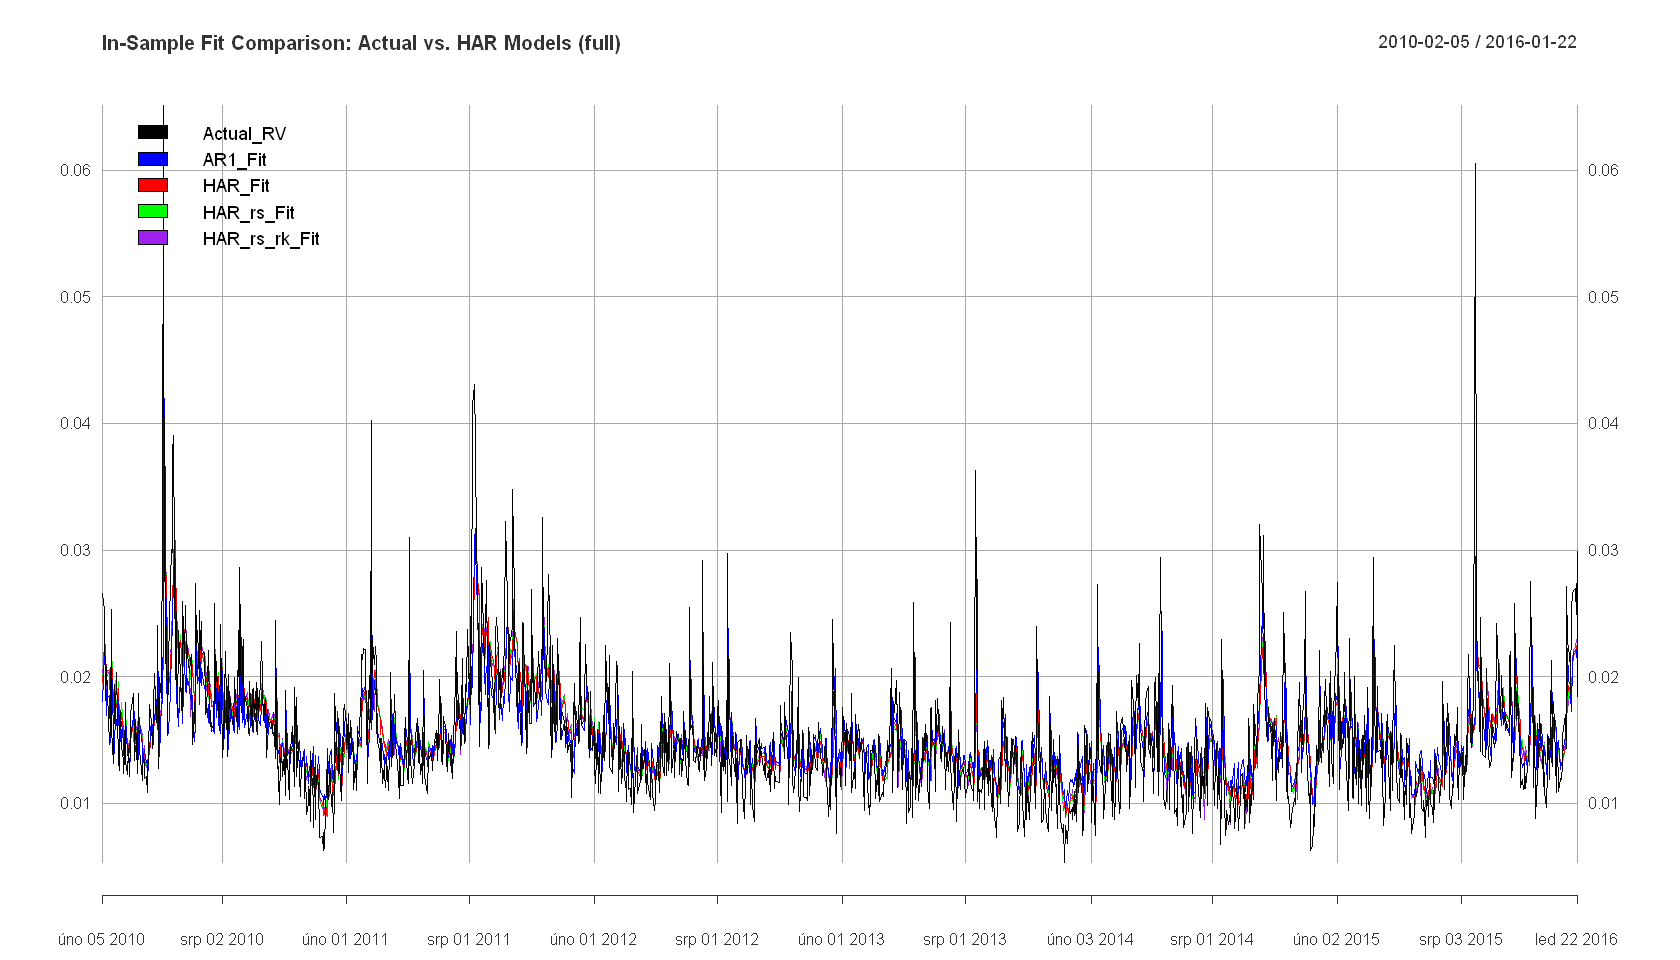

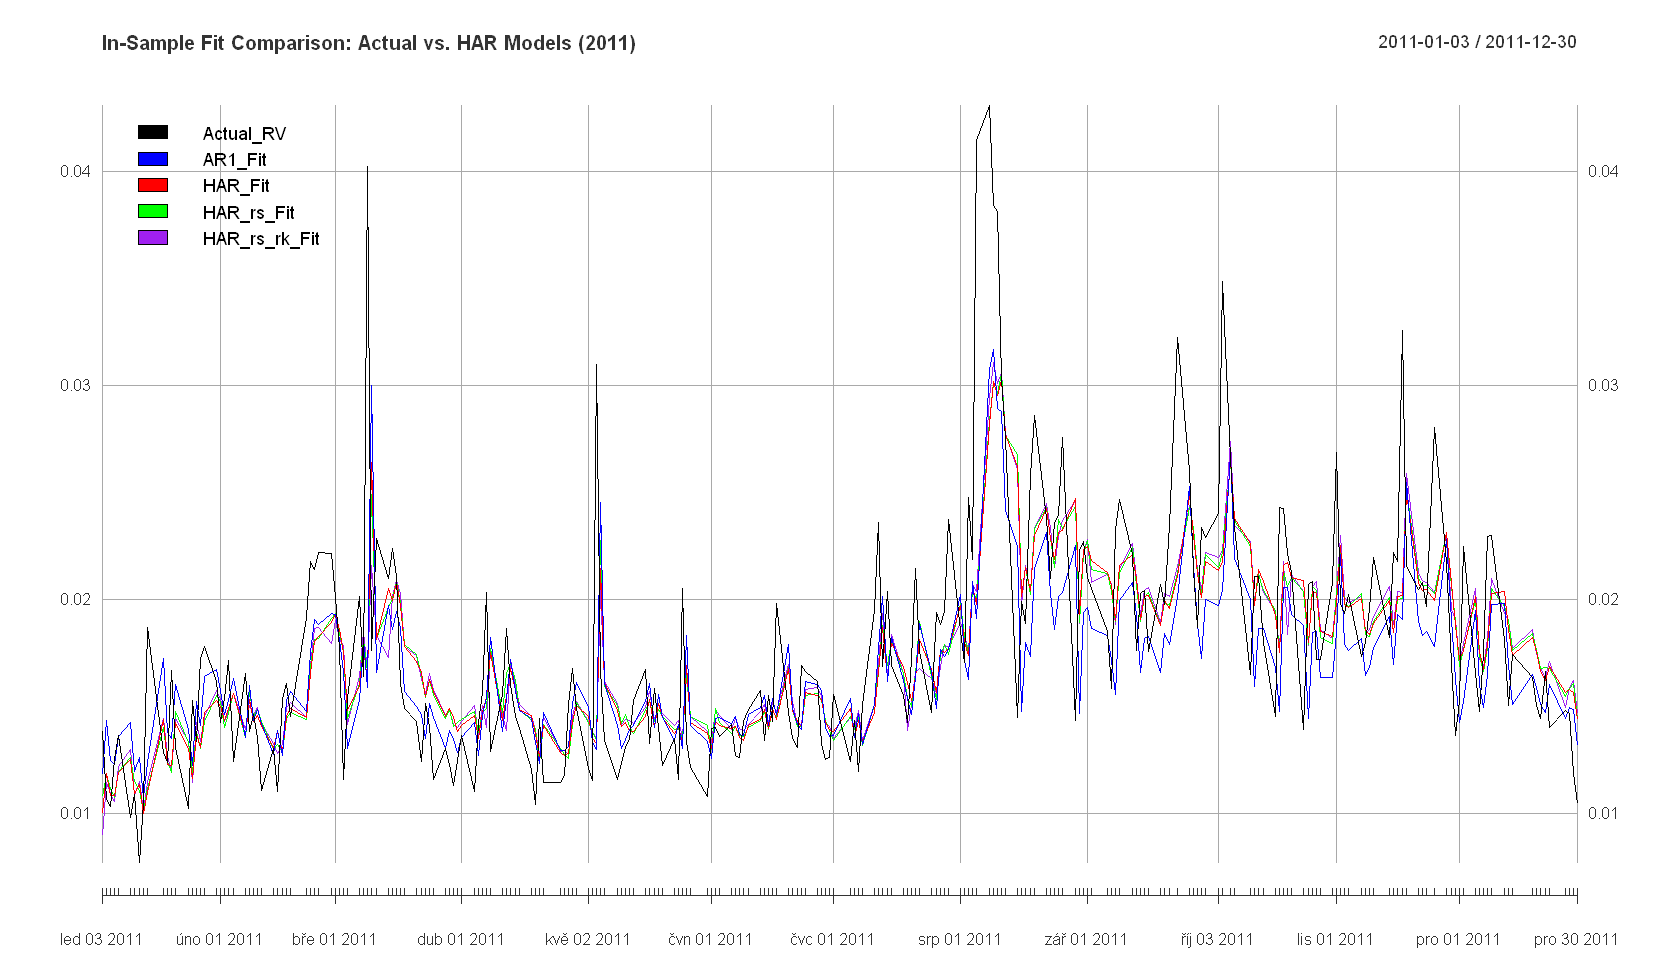

In [20]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "blue", "red", "green", "purple"),
         lwd = 0.6,
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (full)",
         legend.loc = "topleft")

options(repr.plot.width = 14, repr.plot.height = 8)

#zoom in on 2011 for example
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, 
         col = c("black", "blue", "red", "green", "purple"),
         lwd = 0.9,
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (2011)",
         legend.loc = "topleft")

The set of plots above compares the actual realized volatility (Actual_RV) against the fitted values from the Heterogeneous Autoregressive (HAR) family of models, both over the full sample (2010–2016) and a magnified view of a highly volatile year (2011). Visually, all models in the HAR family—including the base AR(1), standard HAR, HAR_rs, and HAR_rs_rk—track the general contour of the actual volatility remarkably closely. They successfully capture the persistence and mean-reverting nature of the series. However, a closer look at the 2011 zoomed-in plot reveals that while these models adapt quickly to shifting volatility regimes, they systematically under-predict the extreme, sudden spikes in volatility. Furthermore, the fitted lines for the different HAR extensions are tightly clustered together. This indicates that while adding realized semivariance (rs) and realized kurtosis (rk) may improve statistical criteria, the visual difference in their in-sample fit is marginal compared to the baseline HAR model.

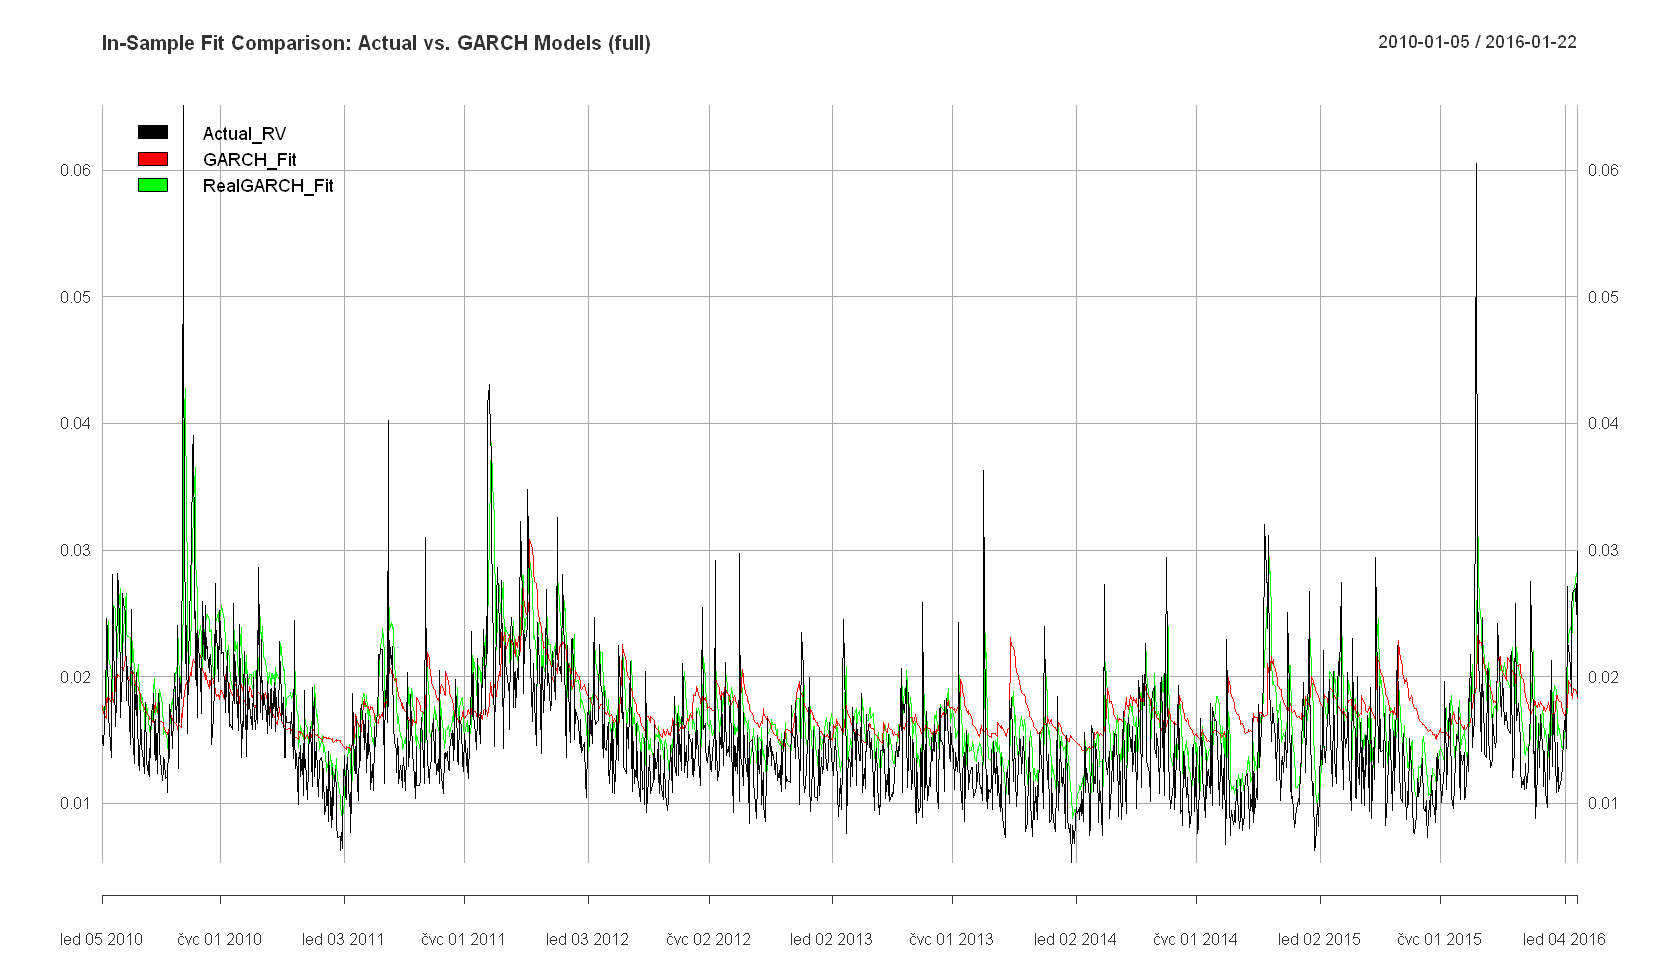

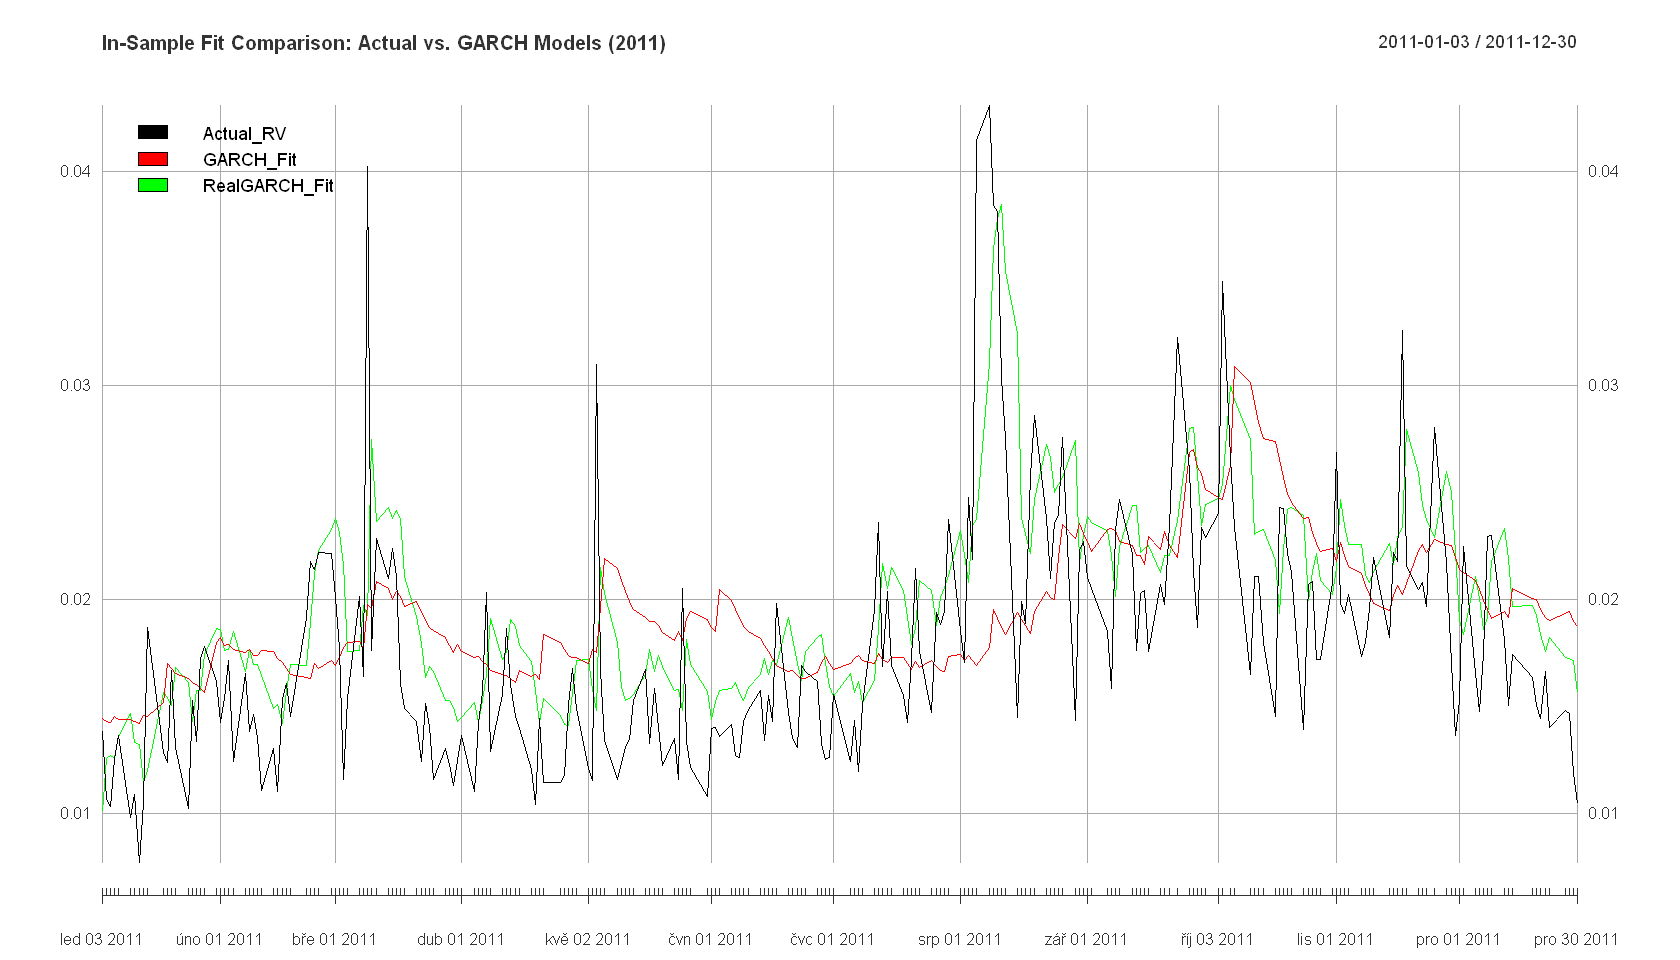

In [21]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         lwd = 0.8,
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models (full)",
         legend.loc = "topleft")

options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         lwd = 0.8,
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models (2011)",
         legend.loc = "topleft")

The second set of plots highlights the stark contrast between traditional return-based volatility models and those that incorporate high-frequency data. The standard GARCH model (GARCH_Fit) produces a visibly sluggish and overly smoothed fitted line. It struggles to react immediately to sudden market shocks, often taking longer to peak and subsequently overestimating volatility during the recovery periods due to its high persistence. Conversely, the Realized GARCH model (RealGARCH_Fit) demonstrates vastly superior responsiveness. While it outperform the GARCH_Fit it strugges to track RV as closely as the afromentioned HAR models, as it is predicting above the RV line for most of the sample. However one key feature that can be seen in the 2011 subsample is the better tracking of large volatility spikes than the HAR family. All in all the lagged nature and slower reverting of GARCH model family can be clearly visible.

## 3. Forecasts

We evaluate the out-of-sample forecasting performance of all six models — AR(1)-RV, HAR,
HAR-RS, HAR-RS-RK, sGARCH and realGARCH — using one-step-ahead forecasts of realized
volatility under two schemes: a **rolling** and an **expanding** window, both with a length
of 750 days. To keep the models comparable, all of them are evaluated on the same common
out-of-sample period.

The section proceeds in three steps:

- **3.1 Forecast construction** - we generate the forecasts for every model under both
window schemes and compare them visually against realized volatility.
- **3.2 Forecast errors and loss functions** - we plot and compare the forecast errors
across all models and summarize accuracy with the MSE and MAE loss functions.
- **3.3 Statistical tests** - we compare the models formally with the Diebold–Mariano test
(predictive accuracy) and assess each forecast with the Mincer–Zarnowitz regression
(unbiasedness and efficiency).


### 3.1 Forecast construction

#### 3.1.1 HAR-family (AR1, HAR, HAR-RS, HAR-RS-RK)
For each out-of-sample day we re-estimate every HAR-family model on the relevant window
and produce a one-step-ahead forecast.

In [22]:
window_len <- 750
n_obs <- nrow(har_data)
out_sample_len <- n_obs - window_len

In [23]:
fcst_ar1_roll <- numeric(out_sample_len)
fcst_har_roll <- numeric(out_sample_len)
fcst_har_rs_roll <- numeric(out_sample_len)
fcst_har_rs_rk_roll <- numeric(out_sample_len)

fcst_ar1_exp <- numeric(out_sample_len)
fcst_har_exp <- numeric(out_sample_len)
fcst_har_rs_exp <- numeric(out_sample_len)
fcst_har_rs_rk_exp <- numeric(out_sample_len)

# Actual values for the out-of-sample period to compare against
actual_out_sample <- har_data$RV[(window_len + 1):n_obs]

In [24]:
for (i in 1:out_sample_len) {
  
  # Rolling Window 
  train_data_roll <- har_data[i:(window_len + i - 1), ]
  
  # Expanding Window 
  train_data_exp <- har_data[1:(window_len + i - 1), ]
  
  # The row of data we are using to predict tomorrow's RV
  test_data <- har_data[(window_len + i), ]
  
  # --- ROLLING WINDOW FITS & FORECASTS ---
  fit_ar1_roll <- lm(RV ~ RV_1, data = train_data_roll)
  fit_har_roll <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_roll)
  fit_har_rs_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_roll)
  fit_har_rs_rk_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_roll)
    
  fcst_ar1_roll[i] <- predict(fit_ar1_roll, newdata = test_data)
  fcst_har_roll[i] <- predict(fit_har_roll, newdata = test_data)
  fcst_har_rs_roll[i] <- predict(fit_har_rs_roll, newdata = test_data)  
  fcst_har_rs_rk_roll[i] <- predict(fit_har_rs_rk_roll, newdata = test_data) 
    
  # --- EXPANDING WINDOW FITS & FORECASTS ---
  fit_ar1_exp <- lm(RV ~ RV_1, data = train_data_exp)
  fit_har_exp <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_exp)
  fit_har_rs_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_exp)
  fit_har_rs_rk_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_exp)
    
  fcst_ar1_exp[i] <- predict(fit_ar1_exp, newdata = test_data)
  fcst_har_exp[i] <- predict(fit_har_exp, newdata = test_data)
  fcst_har_rs_exp[i] <- predict(fit_har_rs_exp, newdata = test_data)  
  fcst_har_rs_rk_exp[i] <- predict(fit_har_rs_rk_exp, newdata = test_data)   
}

In [25]:
# Helper function to calculate MSE and MAE
calc_loss <- function(actual, forecast) {
  error <- actual - forecast
  mse <- mean(error^2, na.rm = TRUE)
  mae <- mean(abs(error), na.rm = TRUE)
  return(c(MSE = mse, MAE = mae))
}

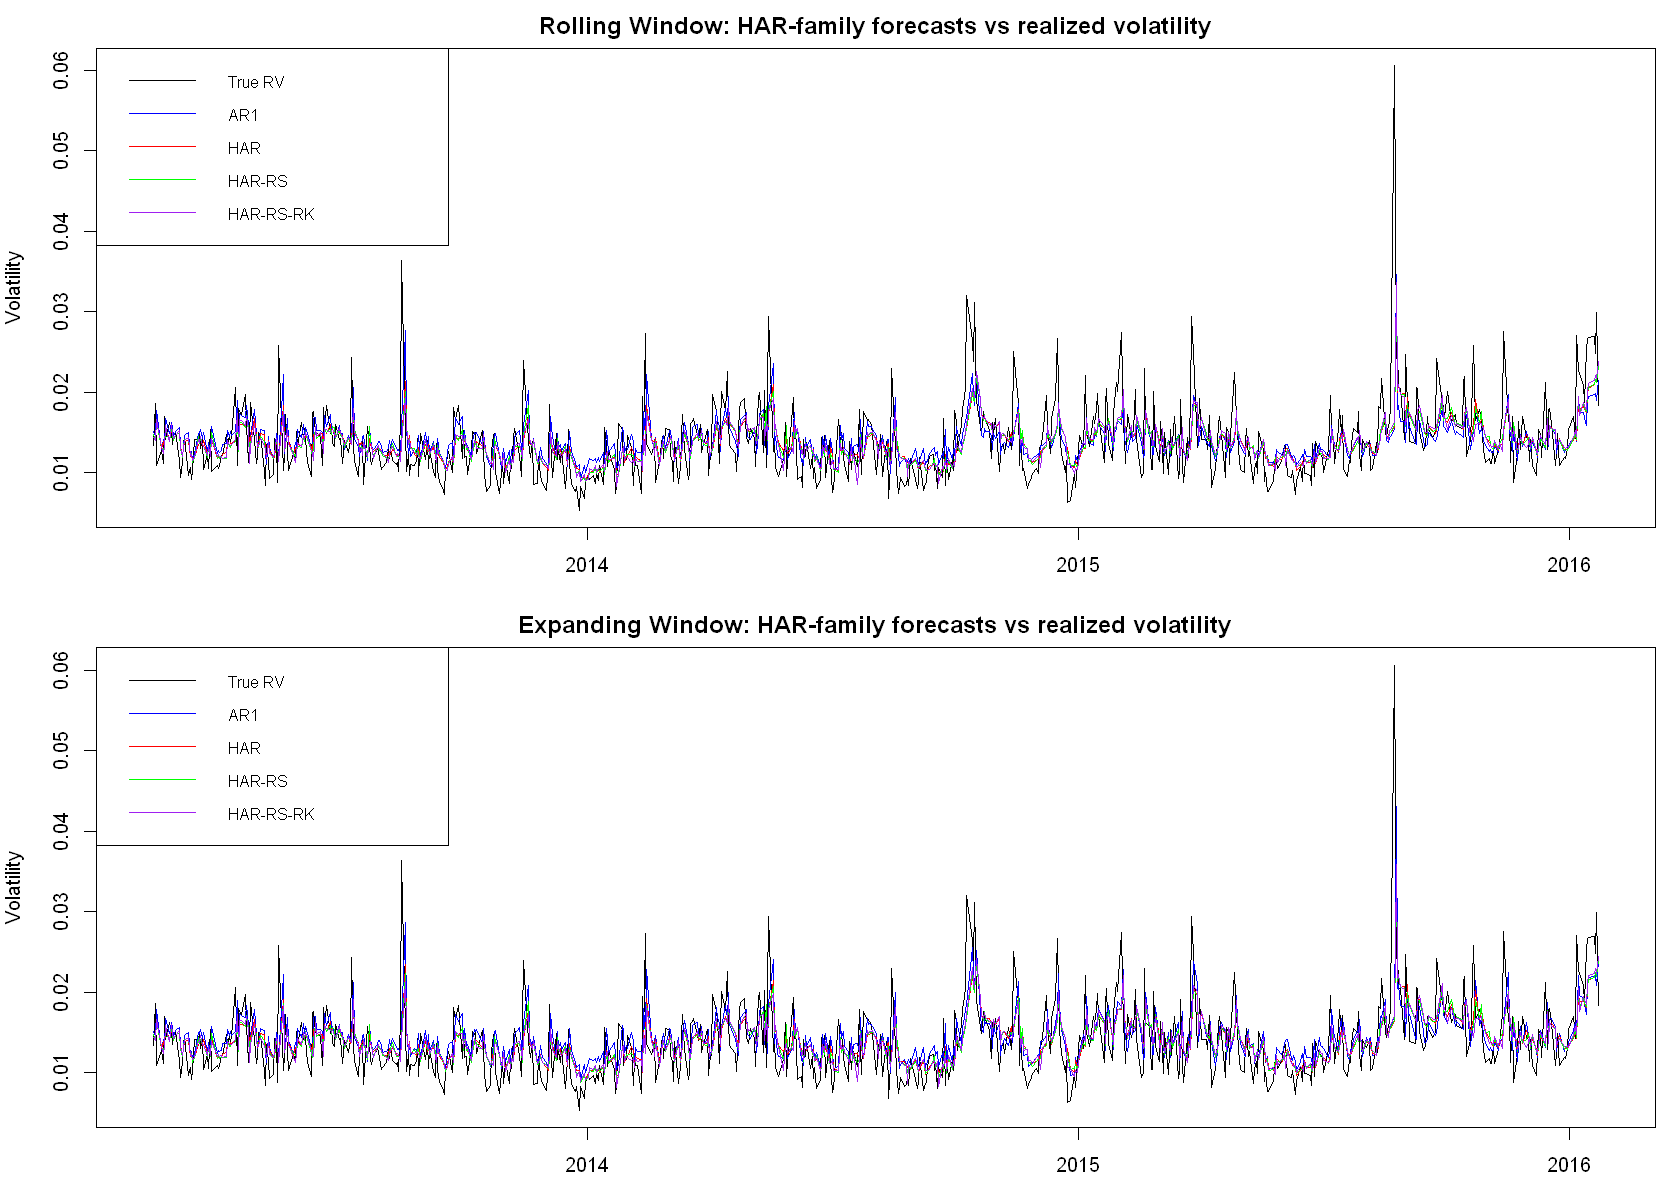

In [26]:
# 3.2 — HAR-family forecasts vs realized volatility (rolling & expanding)
options(repr.plot.width = 14, repr.plot.height = 10)
# Date the HAR-family forecasts (still plain numeric) using har_data's out-of-sample index
har_oos_dates <- index(har_data)[(window_len + 1):nrow(har_data)]
har_roll <- xts(cbind(True_RV      = as.numeric(actual_out_sample),
                      AR1_Roll     = fcst_ar1_roll,
                      HAR_Roll     = fcst_har_roll,
                      HARRS_Roll   = fcst_har_rs_roll,
                      HARRSRK_Roll = fcst_har_rs_rk_roll),
                order.by = har_oos_dates)
har_exp  <- xts(cbind(True_RV      = as.numeric(actual_out_sample),
                      AR1_Exp      = fcst_ar1_exp,
                      HAR_Exp      = fcst_har_exp,
                      HARRS_Exp    = fcst_har_rs_exp,
                      HARRSRK_Exp  = fcst_har_rs_rk_exp),
                order.by = har_oos_dates)
cols <- c("black", "blue", "red", "green", "purple")
par(mfrow = c(2, 1), mar = c(3, 4, 2, 1))
plot.zoo(har_roll, plot.type = "single", col = cols, lwd = 0.8,
       main = "Rolling Window: HAR-family forecasts vs realized volatility",
       ylab = "Volatility", xlab = "")
legend("topleft", legend = c("True RV","AR1","HAR","HAR-RS","HAR-RS-RK"), col = cols, lty = 1, cex = 0.8)
plot.zoo(har_exp, plot.type = "single", col = cols, lwd = 0.8,
       main = "Expanding Window: HAR-family forecasts vs realized volatility",
       ylab = "Volatility", xlab = "Date")
legend("topleft", legend = c("True RV","AR1","HAR","HAR-RS","HAR-RS-RK"), col = cols, lty = 1, cex = 0.8)
par(mfrow = c(1, 1))

#### 3.1.2 GARCH models (sGARCH and realGARCH)
Next, we perform the out-of-sample forecasts for the GARCH models. While sGARCH is rolled with ugarchroll, realGARCH is forecast with a manual daily-refit loop that filters each day forward and guards against degenerate fits. Both are produced under the moving and expanding schemes.

In [27]:
  # ============================================================
  # GARCH FORECASTS — SETUP 
  # all forecasts are on the volatility scale (sigma).
  # ============================================================
  
  window_len      <- 750
  n_obs           <- nrow(asset_data)
  n_out_of_sample <- n_obs - window_len
  idx             <- as.Date(index(asset_data))
  oos_dates       <- tail(idx, n_out_of_sample)
  oos_indices     <- (window_len + 1):n_obs
  
  # scale x100, jitter the few exact-zero returns; RV passed as volatility (no sqrt)
  safe_ret <- as.numeric(asset_data$ret); safe_ret[safe_ret == 0] <- 1e-6
  returns_xts <- xts(safe_ret * 100,                  order.by = idx)
  rv_xts      <- xts(as.numeric(asset_data$RV) * 100, order.by = idx)

  make_spec_std  <- function() ugarchspec(
    variance.model = list(model = "sGARCH",   garchOrder = c(1, 1)),
    mean.model     = list(armaOrder = c(0, 0), include.mean = FALSE),
    distribution.model = "norm")
  make_spec_real <- function() ugarchspec(
    variance.model = list(model = "realGARCH", garchOrder = c(1, 1)),
    mean.model     = list(armaOrder = c(0, 0), include.mean = FALSE),
    distribution.model = "norm")

  cat("Setup done. rugarch", as.character(packageVersion("rugarch")),
      "| OOS days:", n_out_of_sample, "\n")

Setup done. rugarch 1.5.5 | OOS days: 750 


##### sGARCH - moving

sGARCH moving done. range: 0.0133 0.0283 


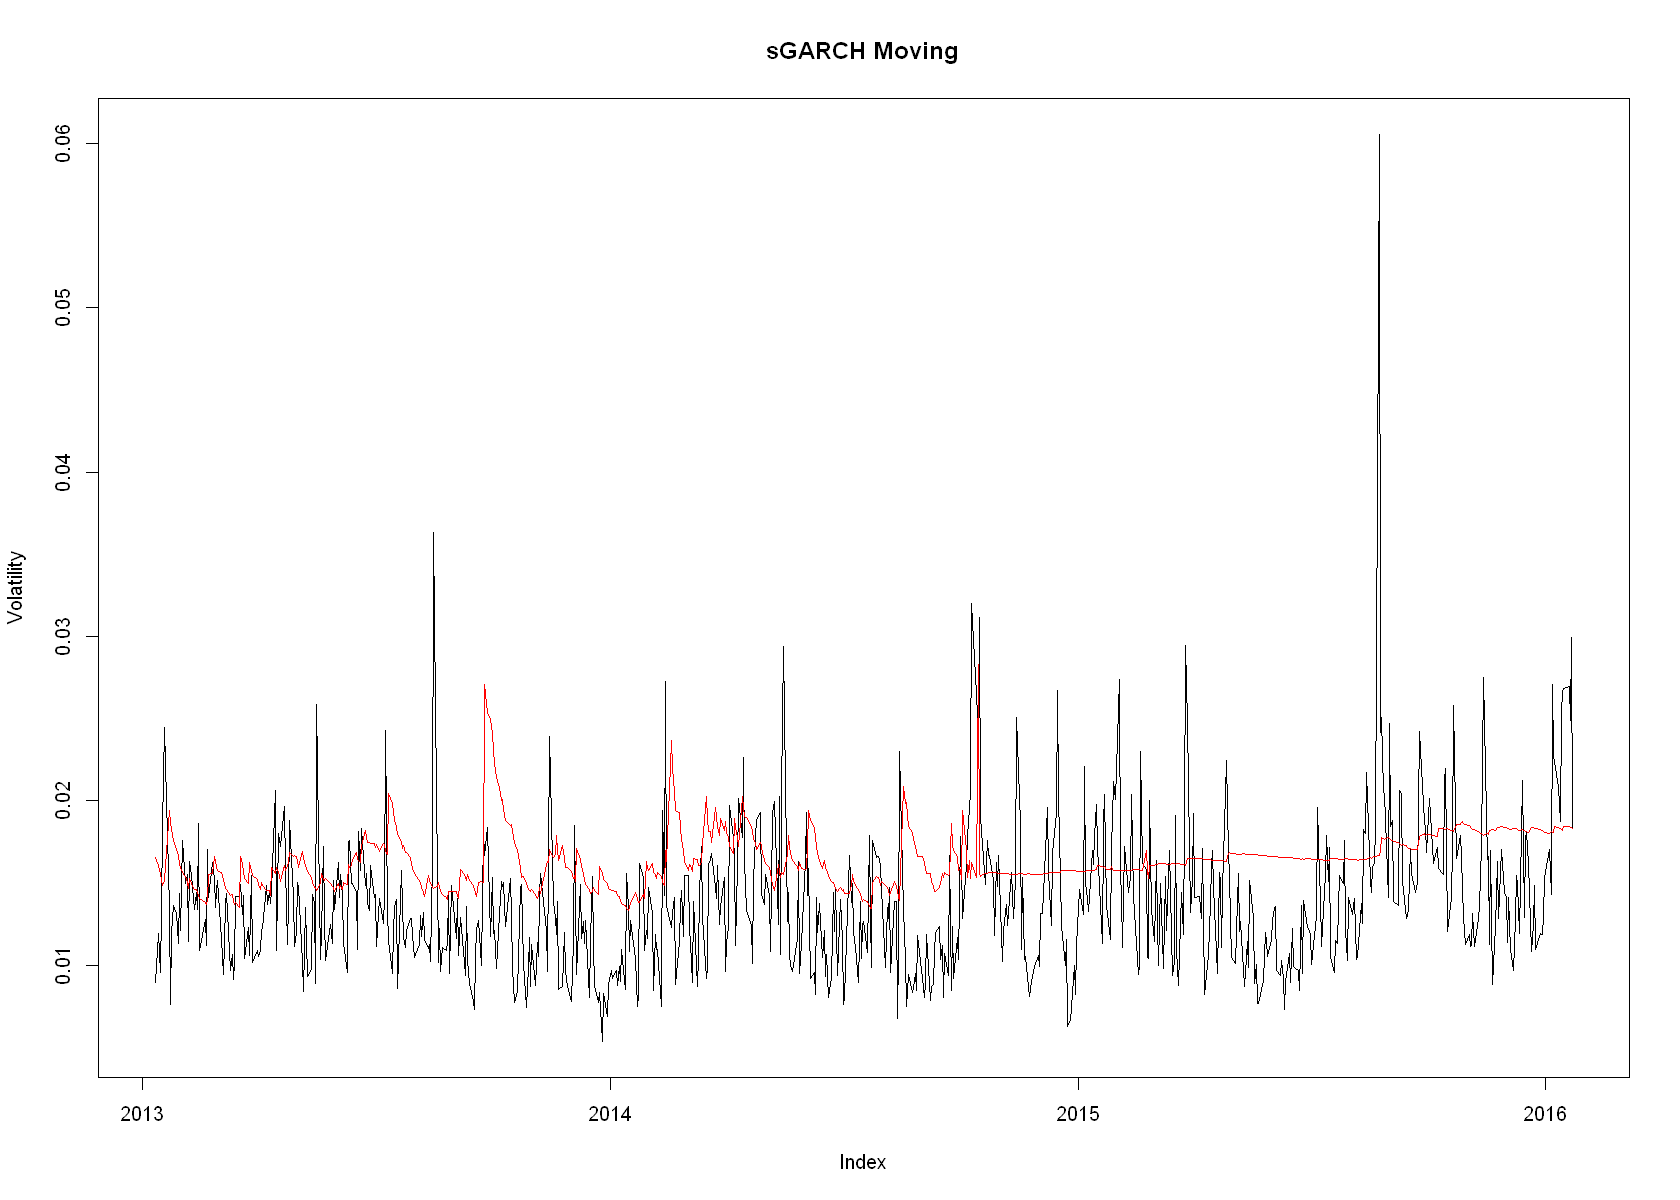

In [28]:
# --- sGARCH, MOVING window (daily refit, parallelised) ---
set.seed(1)
cl <- makePSOCKcluster(max(1, detectCores() - 1))
roll_std_mov <- ugarchroll(make_spec_std(), data = returns_xts, n.ahead = 1,
                         forecast.length = n_out_of_sample, refit.every = 1,
                         refit.window = "moving", window.size = window_len,
                         solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
stopCluster(cl)
f_sgarch_mov <- xts(roll_std_mov@forecast$density$Sigma / 100, order.by = oos_dates)
colnames(f_sgarch_mov) <- "sGARCH_Moving"
plot.zoo(merge(xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), oos_dates), f_sgarch_mov),
       screens = 1, col = c("black", "red"), main = "sGARCH Moving", ylab = "Volatility")
cat("sGARCH moving done. range:", round(range(f_sgarch_mov), 4), "\n")

##### sGARCH - expanding

sGARCH expanding done. range: 0.0127 0.0269 


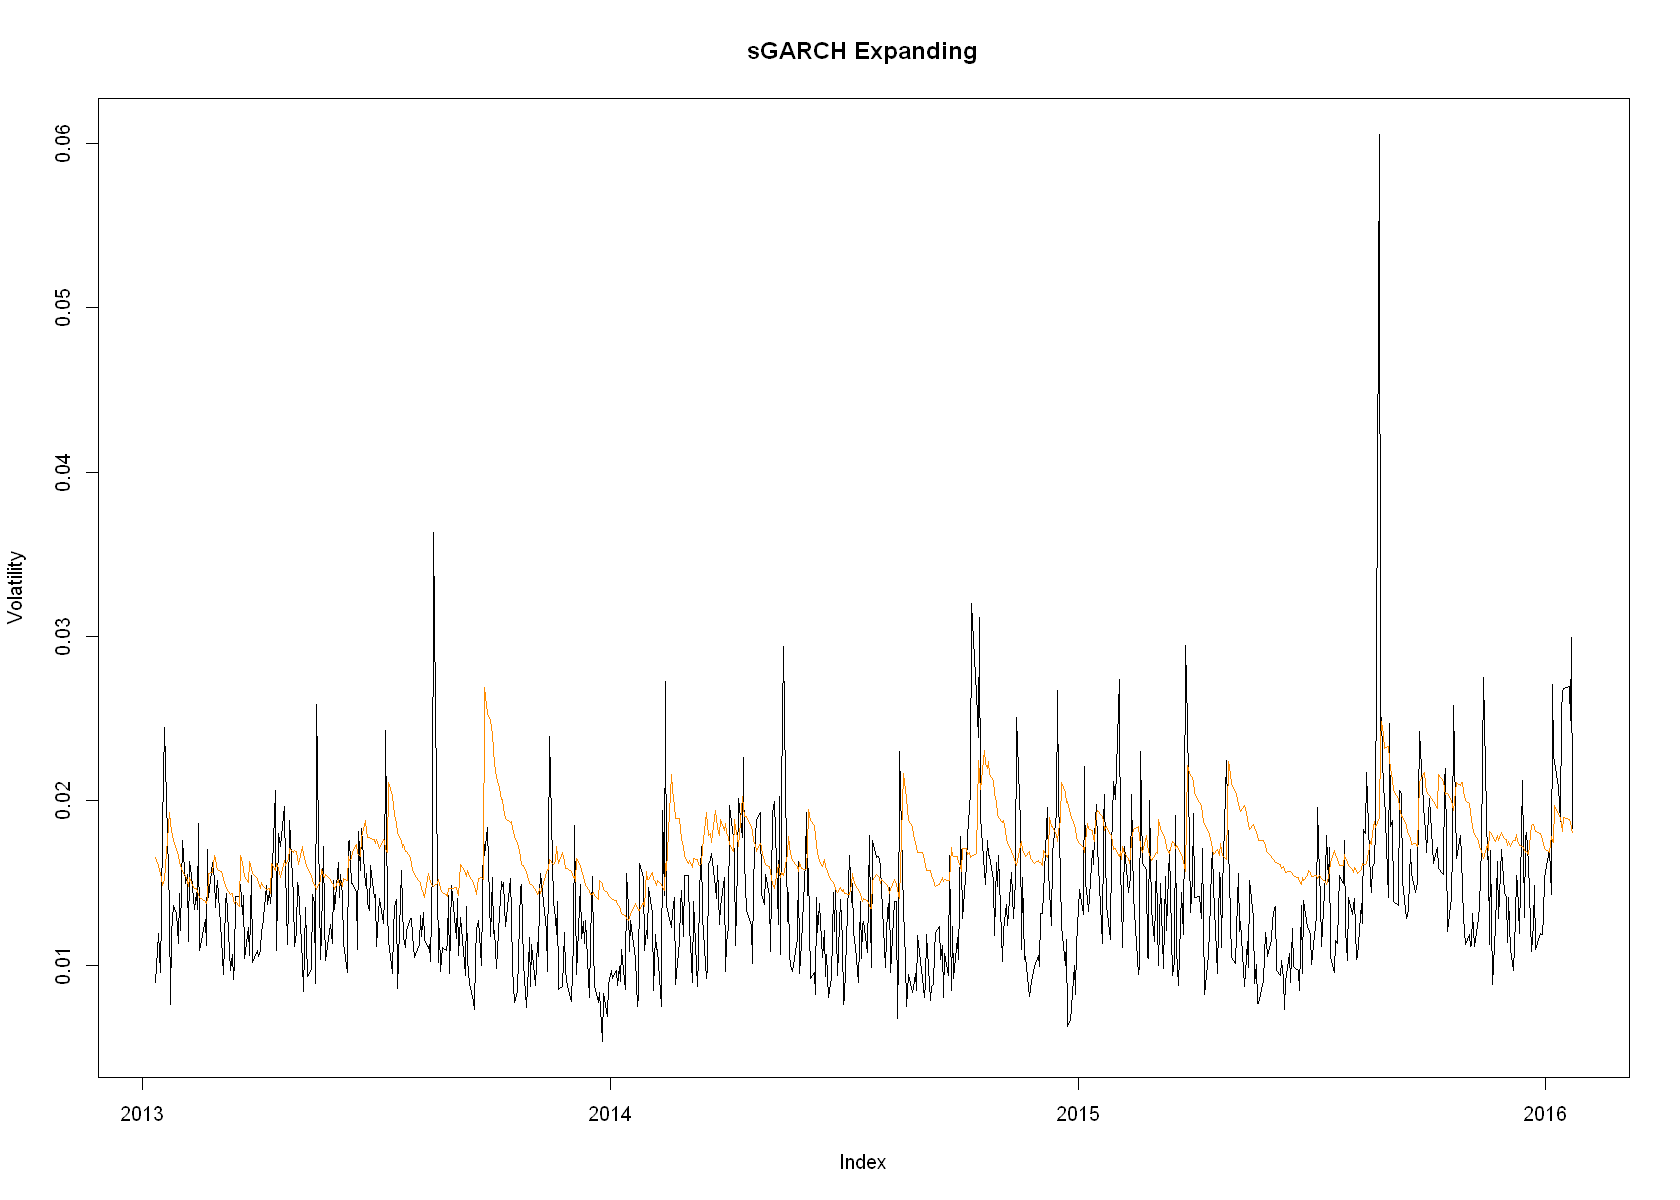

In [29]:
# --- sGARCH, EXPANDING window (daily refit, parallelised) ---
set.seed(1)
cl <- makePSOCKcluster(max(1, detectCores() - 1))
roll_std_exp <- ugarchroll(make_spec_std(), data = returns_xts, n.ahead = 1,
                         forecast.length = n_out_of_sample, refit.every = 1,
                         refit.window = "recursive",
                         solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
stopCluster(cl)
f_sgarch_exp <- xts(roll_std_exp@forecast$density$Sigma / 100, order.by = oos_dates)
colnames(f_sgarch_exp) <- "sGARCH_Expanding"
plot.zoo(merge(xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), oos_dates), f_sgarch_exp),
       screens = 1, col = c("black", "darkorange"), main = "sGARCH Expanding", ylab = "Volatility")
cat("sGARCH expanding done. range:", round(range(f_sgarch_exp), 4), "\n")

##### realGARCH - moving

  realGARCH moving: 100 / 750 
  realGARCH moving: 200 / 750 
  realGARCH moving: 300 / 750 
  realGARCH moving: 400 / 750 
  realGARCH moving: 500 / 750 
  realGARCH moving: 600 / 750 
  realGARCH moving: 700 / 750 
realGARCH moving done. range: 0.0083 0.0316 


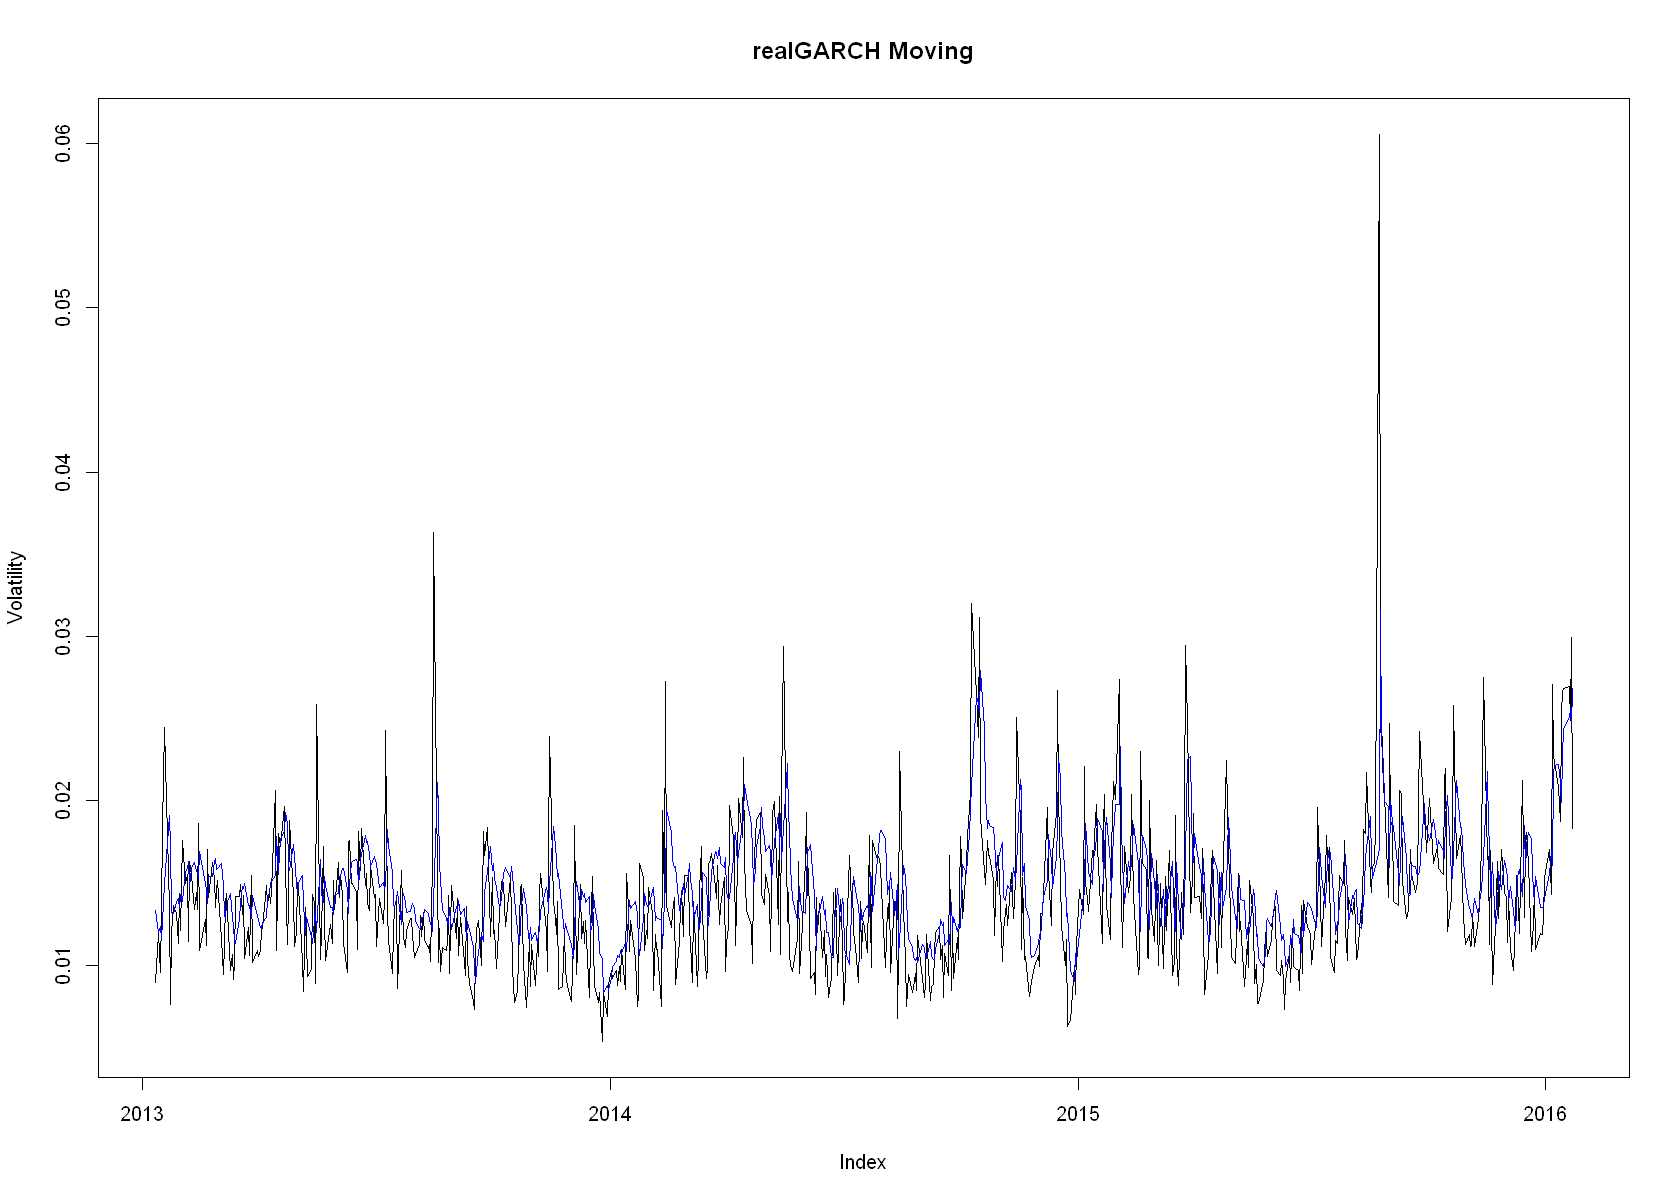

In [30]:
# --- realGARCH, MOVING window (daily refit + plausibility cap + warm start) ---
set.seed(1)
spec_real <- make_spec_real() 
fc <- rep(NA_real_, length(oos_indices)); last_good_coef <- NULL
for (i in seq_along(oos_indices)) {
t <- oos_indices[i]
tr_ret <- returns_xts[(t - window_len):(t - 1)]
tr_rv  <- rv_xts[(t - window_len):(t - 1)]
if (!is.null(last_good_coef)) try(setstart(spec_real) <- as.list(last_good_coef), silent = TRUE)
fit  <- tryCatch(ugarchfit(spec_real, data = tr_ret, realizedVol = tr_rv,
                           solver = "hybrid", fit.control = list(scale = 0)),
                 error = function(e) NULL)
ok   <- !is.null(fit) && fit@fit$convergence == 0
cand <- if (ok) suppressWarnings(as.numeric(sigma(ugarchforecast(fit, n.ahead = 1)))) else NA
cap  <- 2 * max(as.numeric(tr_rv))                 # plausibility cap (scaled units)
if (ok && is.finite(cand) && cand <= cap) {
  fc[i] <- cand; last_good_coef <- coef(fit)        # accept; warm-start next day
} else if (i > 1) {
  fc[i] <- fc[i - 1]                                # reject -> carry last good forecast
}
if (i %% 100 == 0) cat("  realGARCH moving:", i, "/", length(oos_indices), "\n")
}
f_real_mov <- xts(fc / 100, order.by = oos_dates); colnames(f_real_mov) <- "realGARCH_Moving"
plot.zoo(merge(xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), oos_dates), f_real_mov),
       screens = 1, col = c("black", "blue"), main = "realGARCH Moving", ylab = "Volatility")
cat("realGARCH moving done. range:", round(range(f_real_mov, na.rm = TRUE), 4), "\n")

##### realGARCH - expanding

  realGARCH expanding: 100 / 750 
  realGARCH expanding: 200 / 750 
  realGARCH expanding: 300 / 750 
  realGARCH expanding: 400 / 750 
  realGARCH expanding: 500 / 750 
  realGARCH expanding: 600 / 750 
  realGARCH expanding: 700 / 750 
realGARCH expanding done. range: 0.009 0.0305 


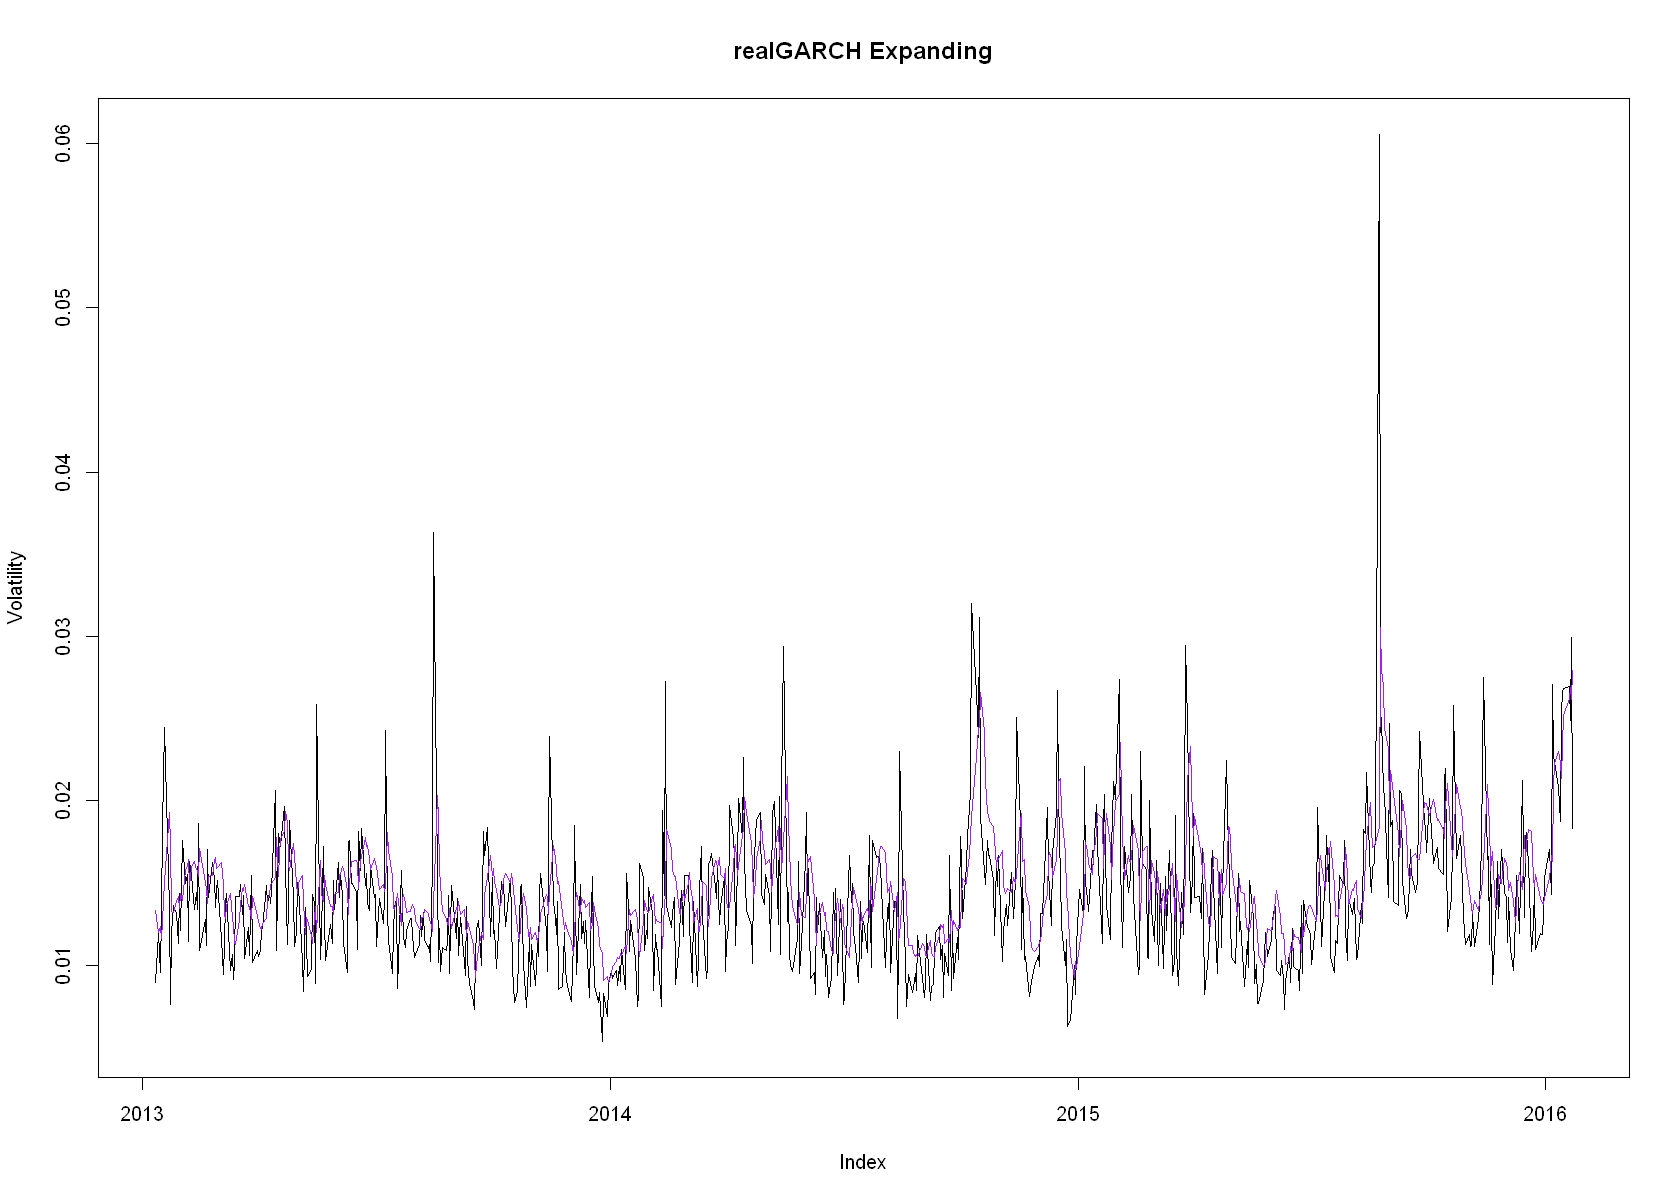

In [31]:
# --- realGARCH, EXPANDING window (daily refit + plausibility cap + warm start) ---
set.seed(1)
spec_real <- make_spec_real()
fc <- rep(NA_real_, length(oos_indices)); last_good_coef <- NULL
for (i in seq_along(oos_indices)) {
t <- oos_indices[i]
tr_ret <- returns_xts[1:(t - 1)]
tr_rv  <- rv_xts[1:(t - 1)]
if (!is.null(last_good_coef)) try(setstart(spec_real) <- as.list(last_good_coef), silent = TRUE)
fit  <- tryCatch(ugarchfit(spec_real, data = tr_ret, realizedVol = tr_rv,
                           solver = "hybrid", fit.control = list(scale = 0)),
                 error = function(e) NULL)
ok   <- !is.null(fit) && fit@fit$convergence == 0
cand <- if (ok) suppressWarnings(as.numeric(sigma(ugarchforecast(fit, n.ahead = 1)))) else NA
cap  <- 2 * max(as.numeric(tr_rv))                 # plausibility cap (scaled units)
if (ok && is.finite(cand) && cand <= cap) {
  fc[i] <- cand; last_good_coef <- coef(fit)
} else if (i > 1) {
  fc[i] <- fc[i - 1]
}
if (i %% 100 == 0) cat("  realGARCH expanding:", i, "/", length(oos_indices), "\n")
}
f_real_exp <- xts(fc / 100, order.by = oos_dates); colnames(f_real_exp) <- "realGARCH_Expanding"
plot.zoo(merge(xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), oos_dates), f_real_exp),
       screens = 1, col = c("black", "purple"), main = "realGARCH Expanding", ylab = "Volatility")
cat("realGARCH expanding done. range:", round(range(f_real_exp, na.rm = TRUE), 4), "\n")

##### plotting it all together

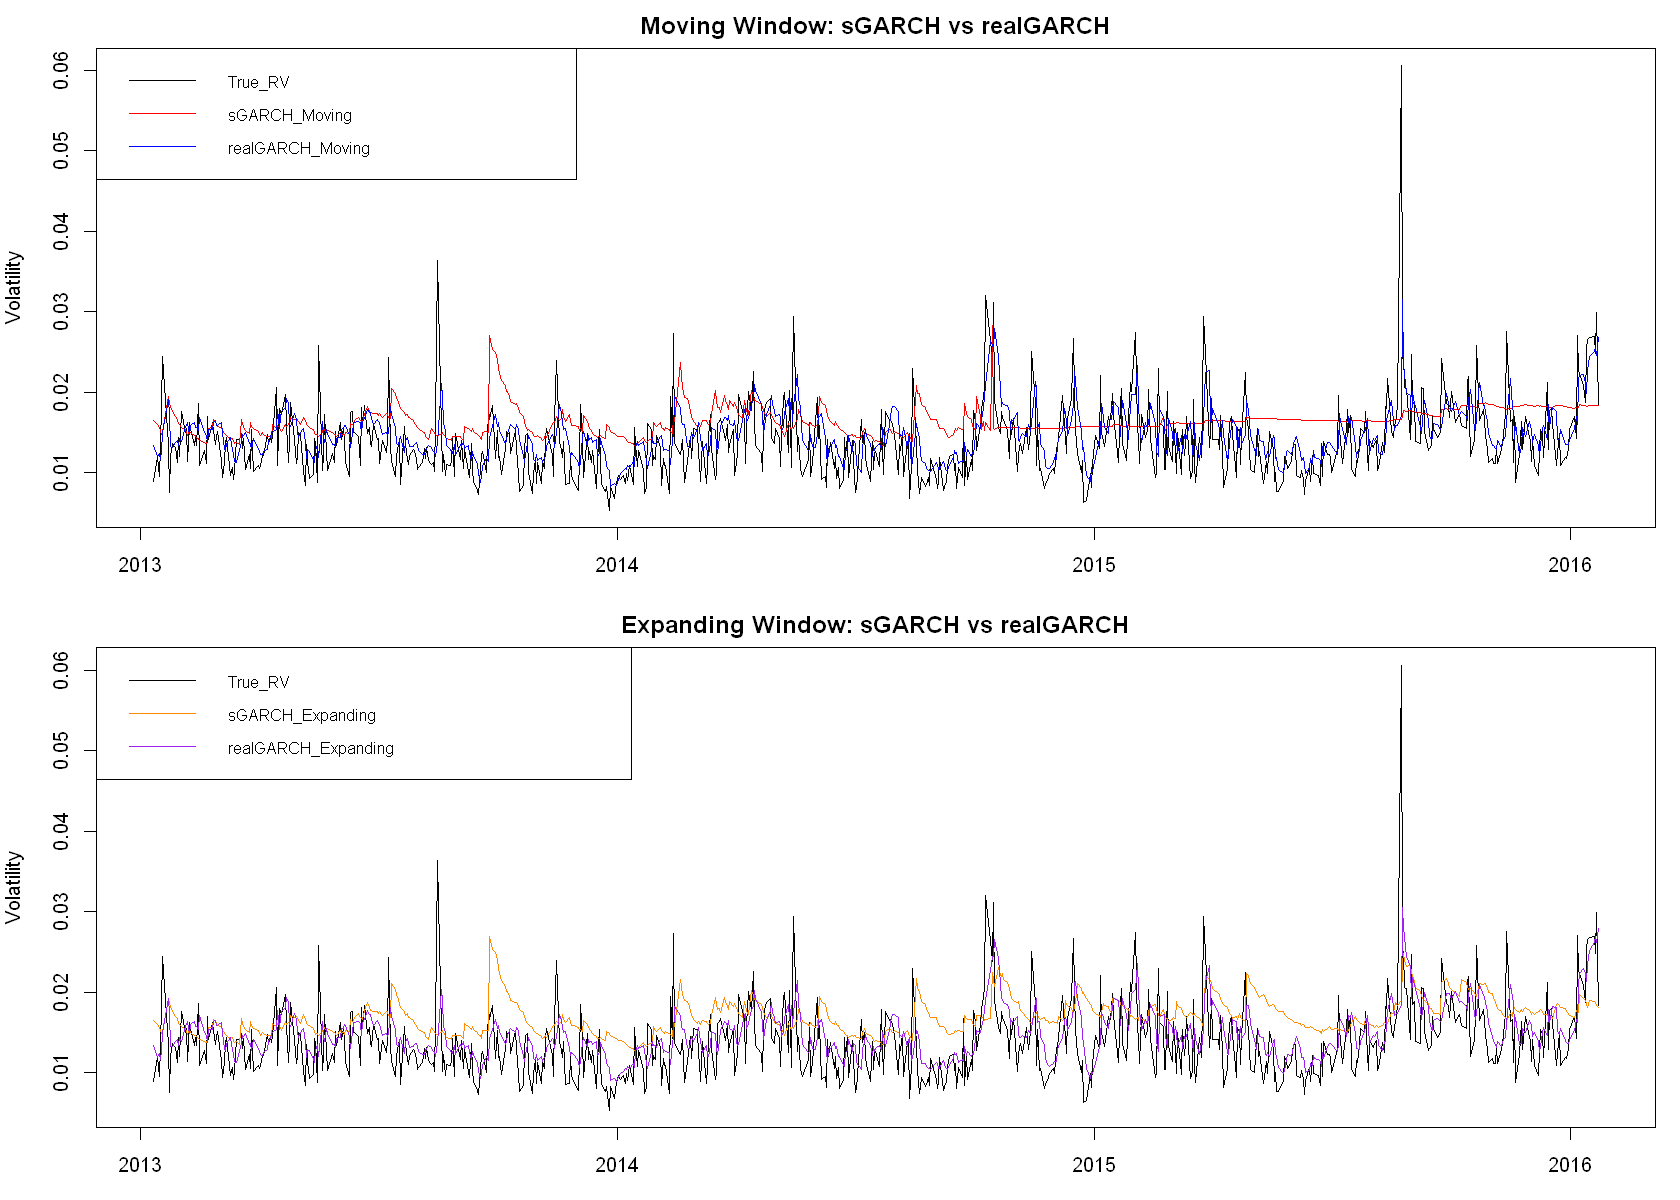

In [32]:
# --- Combined comparison: all GARCH models vs True RV ---
true_rv <- xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), order.by = oos_dates)
colnames(true_rv) <- "True_RV"
plot_data <- merge(true_rv, f_sgarch_mov, f_real_mov, f_sgarch_exp, f_real_exp)

options(repr.plot.width = 14, repr.plot.height = 10)
par(mfrow = c(2, 1), mar = c(3, 4, 2, 1))

mov_cols <- intersect(c("True_RV", "sGARCH_Moving", "realGARCH_Moving"), colnames(plot_data))
plot.zoo(plot_data[, mov_cols], screens = 1,
       col = c("black", "red", "blue")[seq_along(mov_cols)],
       main = "Moving Window: sGARCH vs realGARCH", ylab = "Volatility", xlab = "", lwd = 0.8)
legend("topleft", legend = mov_cols, col = c("black", "red", "blue")[seq_along(mov_cols)], lty = 1, cex = 0.8)

exp_cols <- intersect(c("True_RV", "sGARCH_Expanding", "realGARCH_Expanding"), colnames(plot_data))
plot.zoo(plot_data[, exp_cols], screens = 1,
       col = c("black", "darkorange", "purple")[seq_along(exp_cols)],
       main = "Expanding Window: sGARCH vs realGARCH", ylab = "Volatility", xlab = "Date", lwd = 0.8)
legend("topleft", legend = exp_cols, col = c("black", "darkorange", "purple")[seq_along(exp_cols)], lty = 1, cex = 0.8)

par(mfrow = c(1, 1))

### 3.2 Forecast errors and loss functions

#### 3.2.1 HAR-family

In [48]:
results_matrix <- rbind(
  calc_loss(actual_out_sample, fcst_ar1_roll),
  calc_loss(actual_out_sample, fcst_har_roll),
  calc_loss(actual_out_sample, fcst_har_rs_roll),
  calc_loss(actual_out_sample, fcst_har_rs_rk_roll),
  calc_loss(actual_out_sample, fcst_ar1_exp),
  calc_loss(actual_out_sample, fcst_har_exp),
  calc_loss(actual_out_sample, fcst_har_rs_exp),
  calc_loss(actual_out_sample, fcst_har_rs_rk_exp)
)

rownames(results_matrix) <- c(
  "AR1 (Roll)", "HAR (Roll)", "HAR-RS (Roll)", "HAR-RS-RK (Roll)",
  "AR1 (Exp)", "HAR (Exp)", "HAR-RS (Exp)", "HAR-RS-RK (Exp)"
)

In [49]:
cat("--- OUT-OF-SAMPLE FORECAST EVALUATION ---\n")
print(round(results_matrix, 7))

--- OUT-OF-SAMPLE FORECAST EVALUATION ---
                      MSE       MAE
AR1 (Roll)       1.72e-05 0.0028961
HAR (Roll)       1.60e-05 0.0027697
HAR-RS (Roll)    1.60e-05 0.0027680
HAR-RS-RK (Roll) 1.57e-05 0.0027614
AR1 (Exp)        1.72e-05 0.0029373
HAR (Exp)        1.58e-05 0.0027763
HAR-RS (Exp)     1.57e-05 0.0027720
HAR-RS-RK (Exp)  1.54e-05 0.0027632


In [50]:
err_ar1_roll       <- actual_out_sample - fcst_ar1_roll
err_har_roll       <- actual_out_sample - fcst_har_roll
err_har_rs_roll    <- actual_out_sample - fcst_har_rs_roll
err_har_rs_rk_roll <- actual_out_sample - fcst_har_rs_rk_roll
err_ar1_exp       <- actual_out_sample - fcst_ar1_exp
err_har_exp       <- actual_out_sample - fcst_har_exp
err_har_rs_exp    <- actual_out_sample - fcst_har_rs_exp
err_har_rs_rk_exp <- actual_out_sample - fcst_har_rs_rk_exp

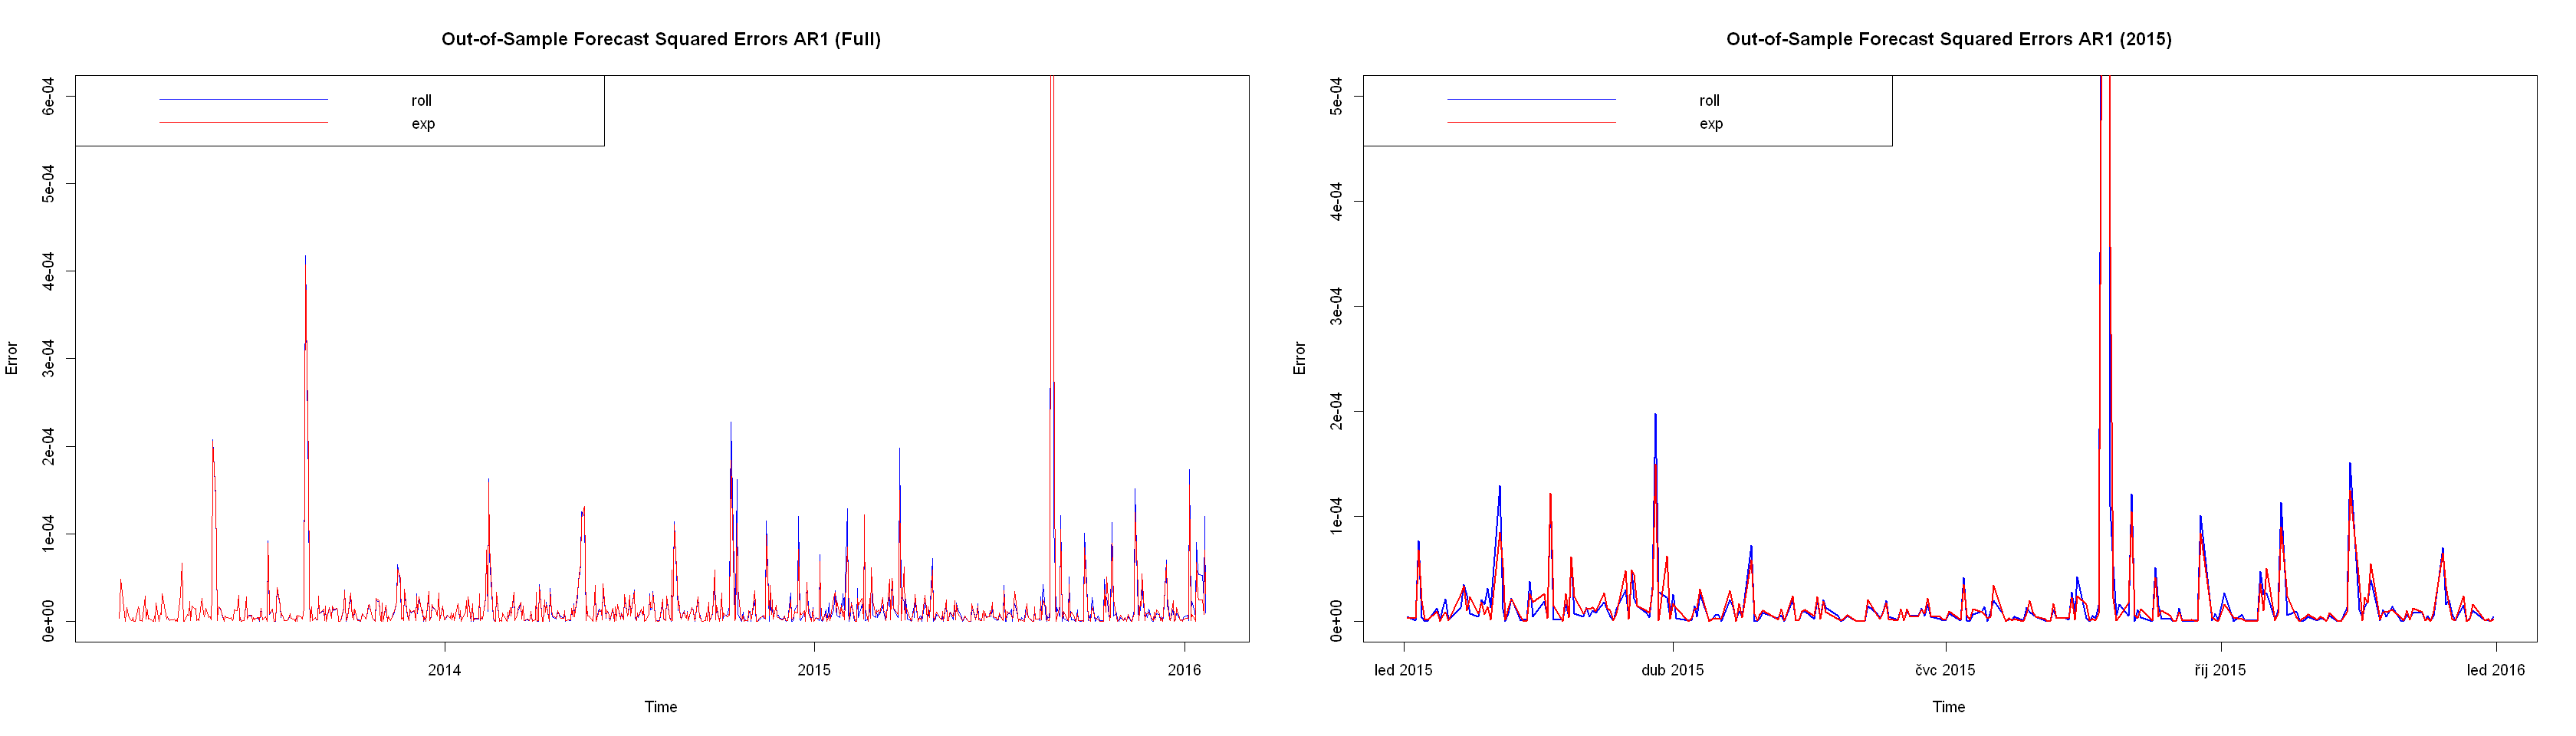

In [51]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
ar1_errors <- merge(err_ar1_roll, err_ar1_exp)
ar1_errors_2015 <- ar1_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(ar1_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors AR1 (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(ar1_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Squared Errors AR1 (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

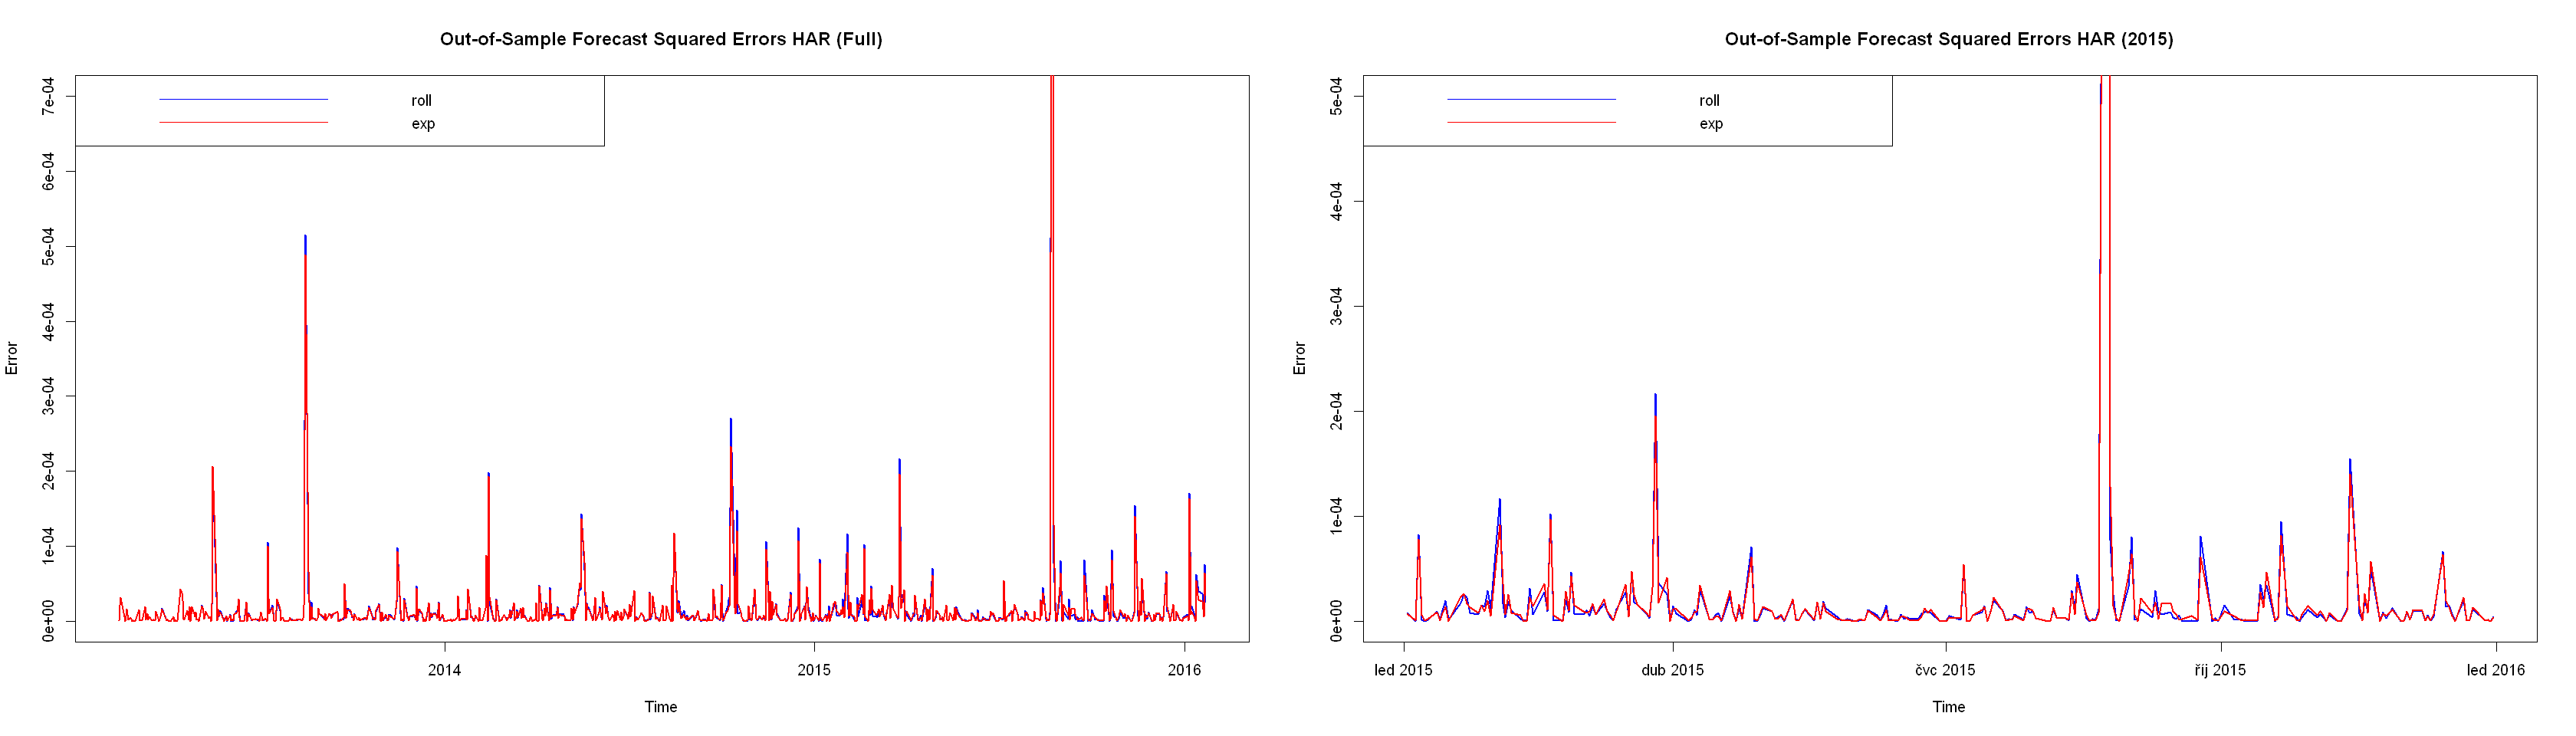

In [52]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
har_errors <- merge(err_har_roll, err_har_exp)
har_errors_2015 <- har_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0007),
            main = "Out-of-Sample Forecast Squared Errors HAR (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Squared Errors HAR (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

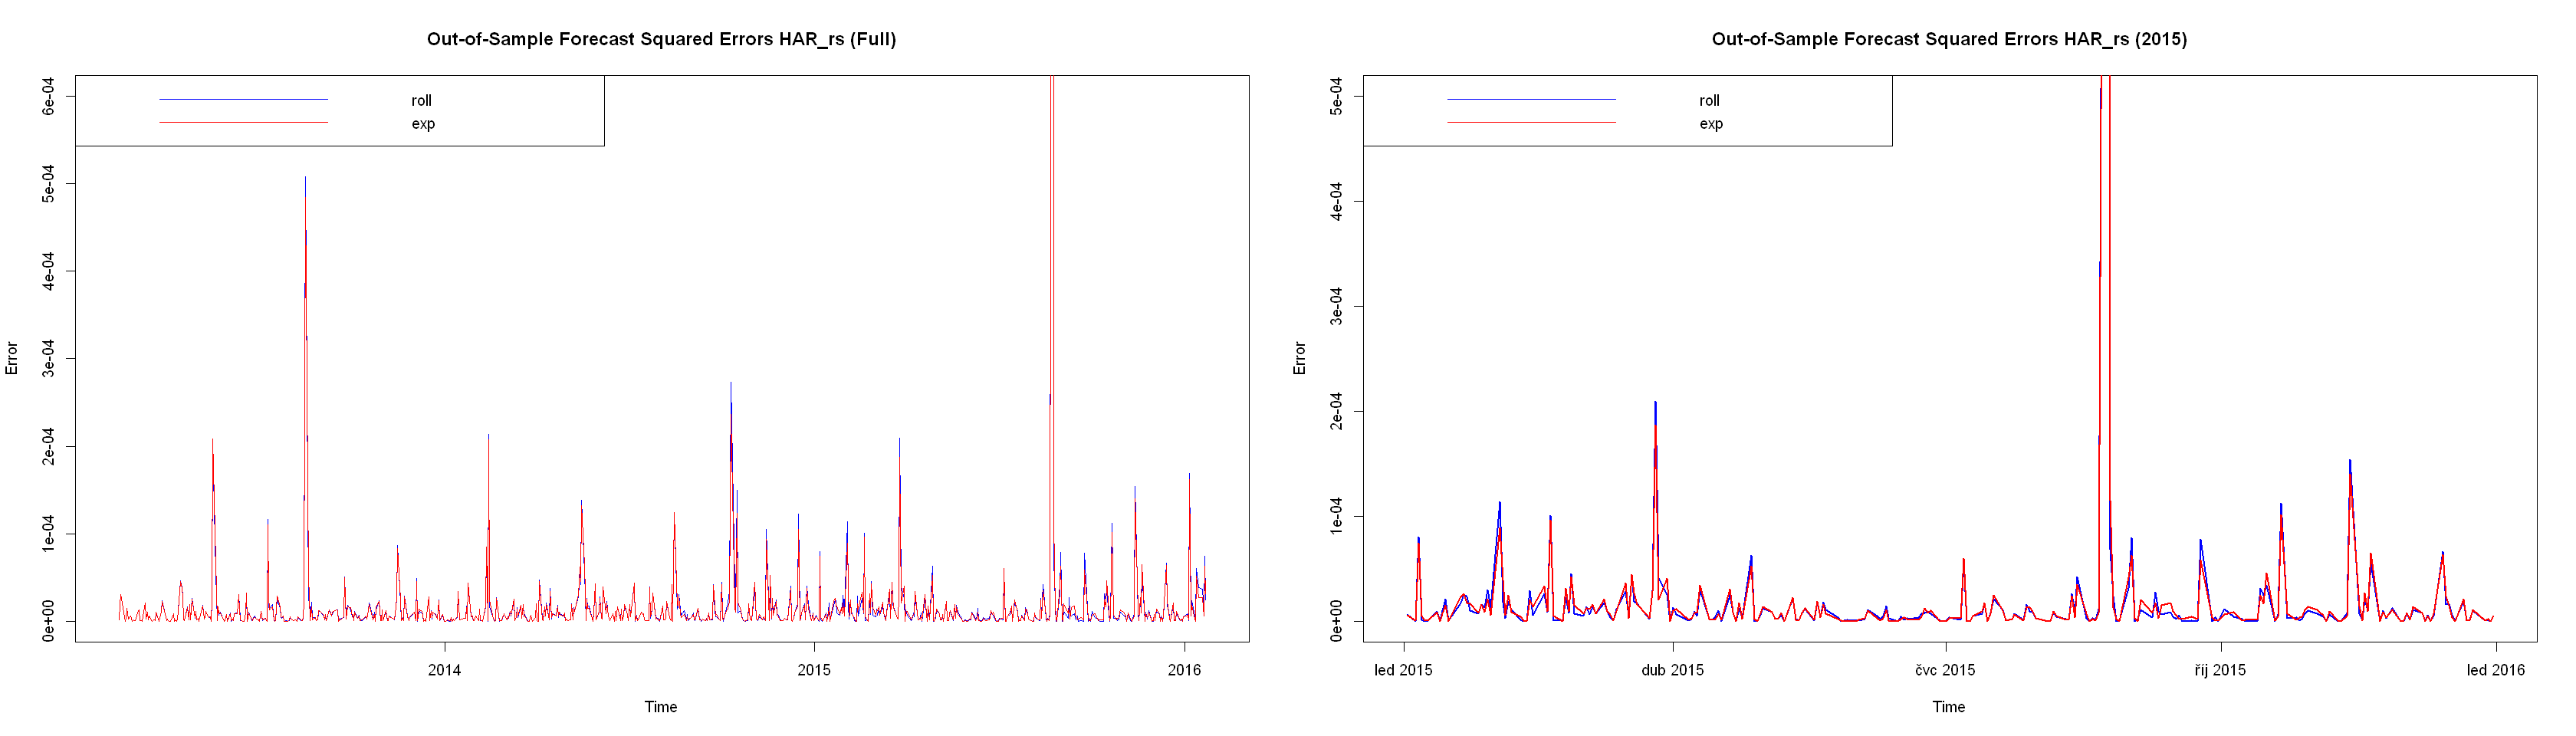

In [38]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_errors <- merge(err_har_rs_roll, err_har_rs_exp)
har_rs_errors_2015 <- har_rs_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors HAR_rs (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Squared Errors HAR_rs (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

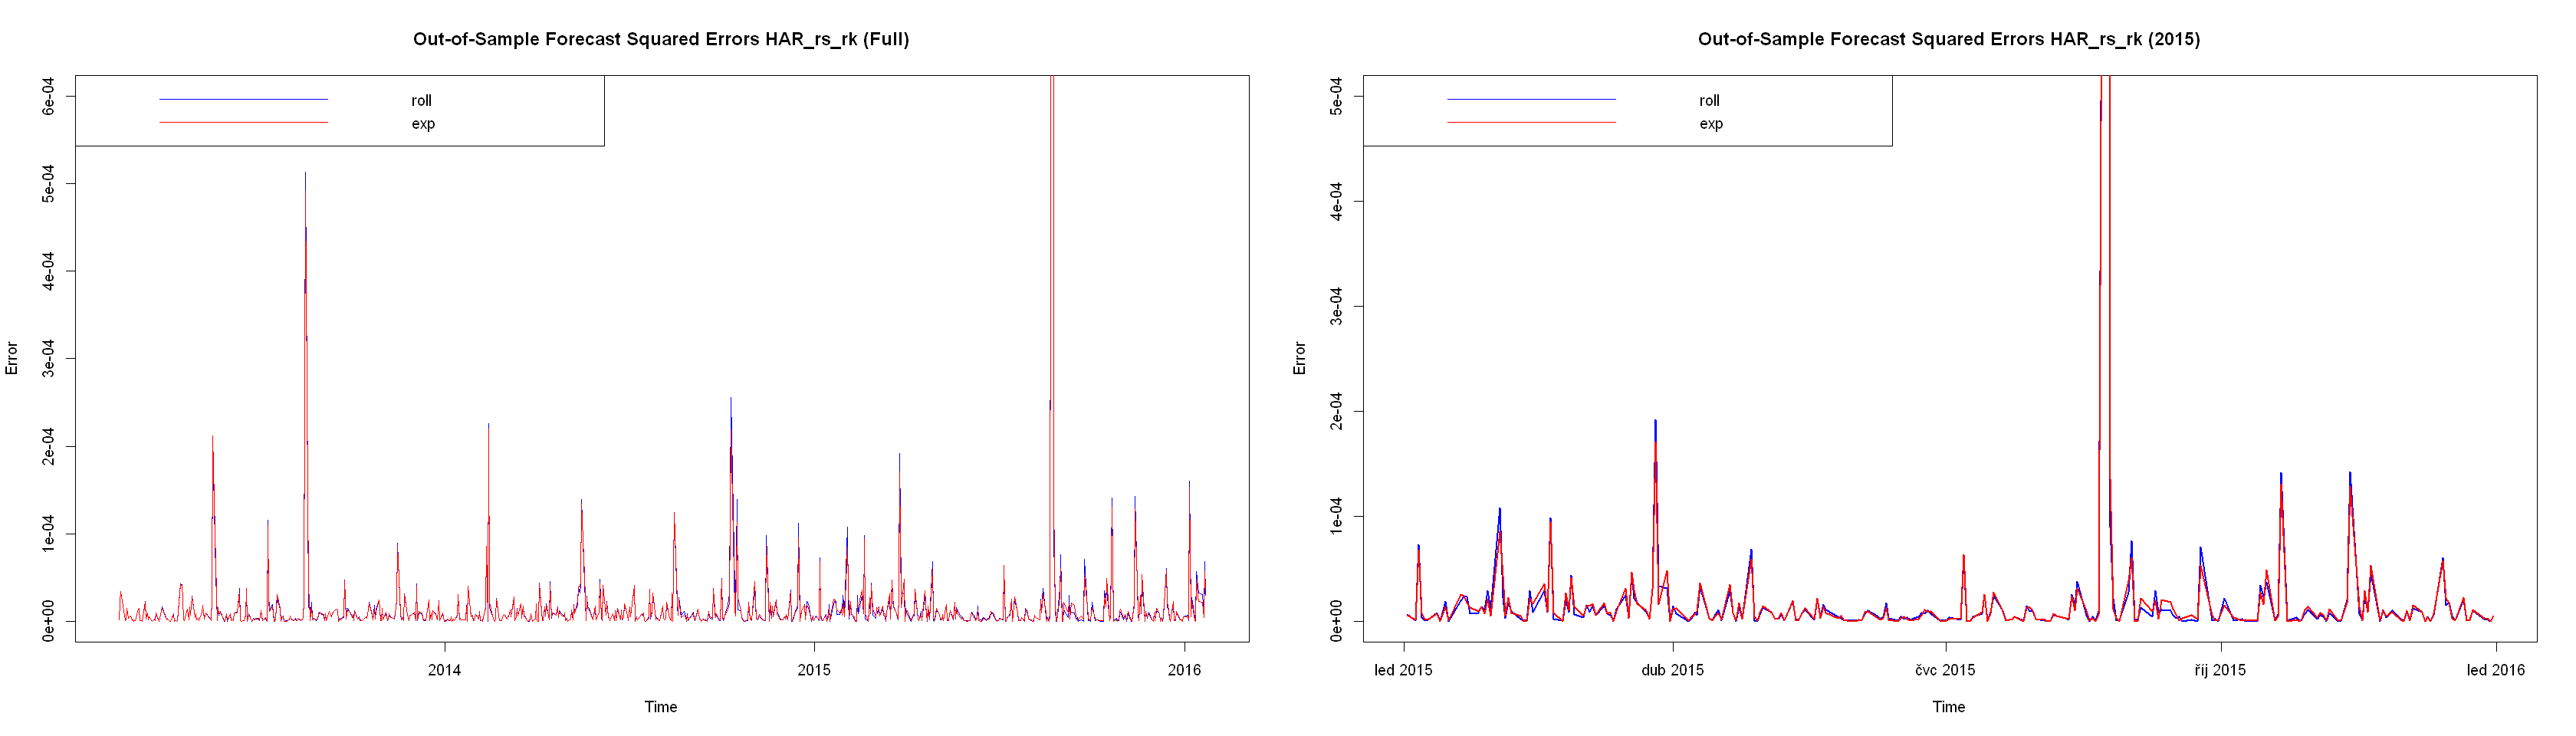

In [39]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_rk_errors <- merge(err_har_rs_rk_roll, err_har_rs_rk_exp)
har_rs_rk_errors_2015 <- har_rs_rk_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_rk_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors HAR_rs_rk (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_rk_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Squared Errors HAR_rs_rk (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

In [40]:
all_errors_roll <- merge(err_ar1_roll, err_har_roll, err_har_rs_roll,err_har_rs_rk_roll)
all_errors_exp <- merge(err_ar1_exp, err_har_exp, err_har_rs_exp, err_har_rs_rk_exp)

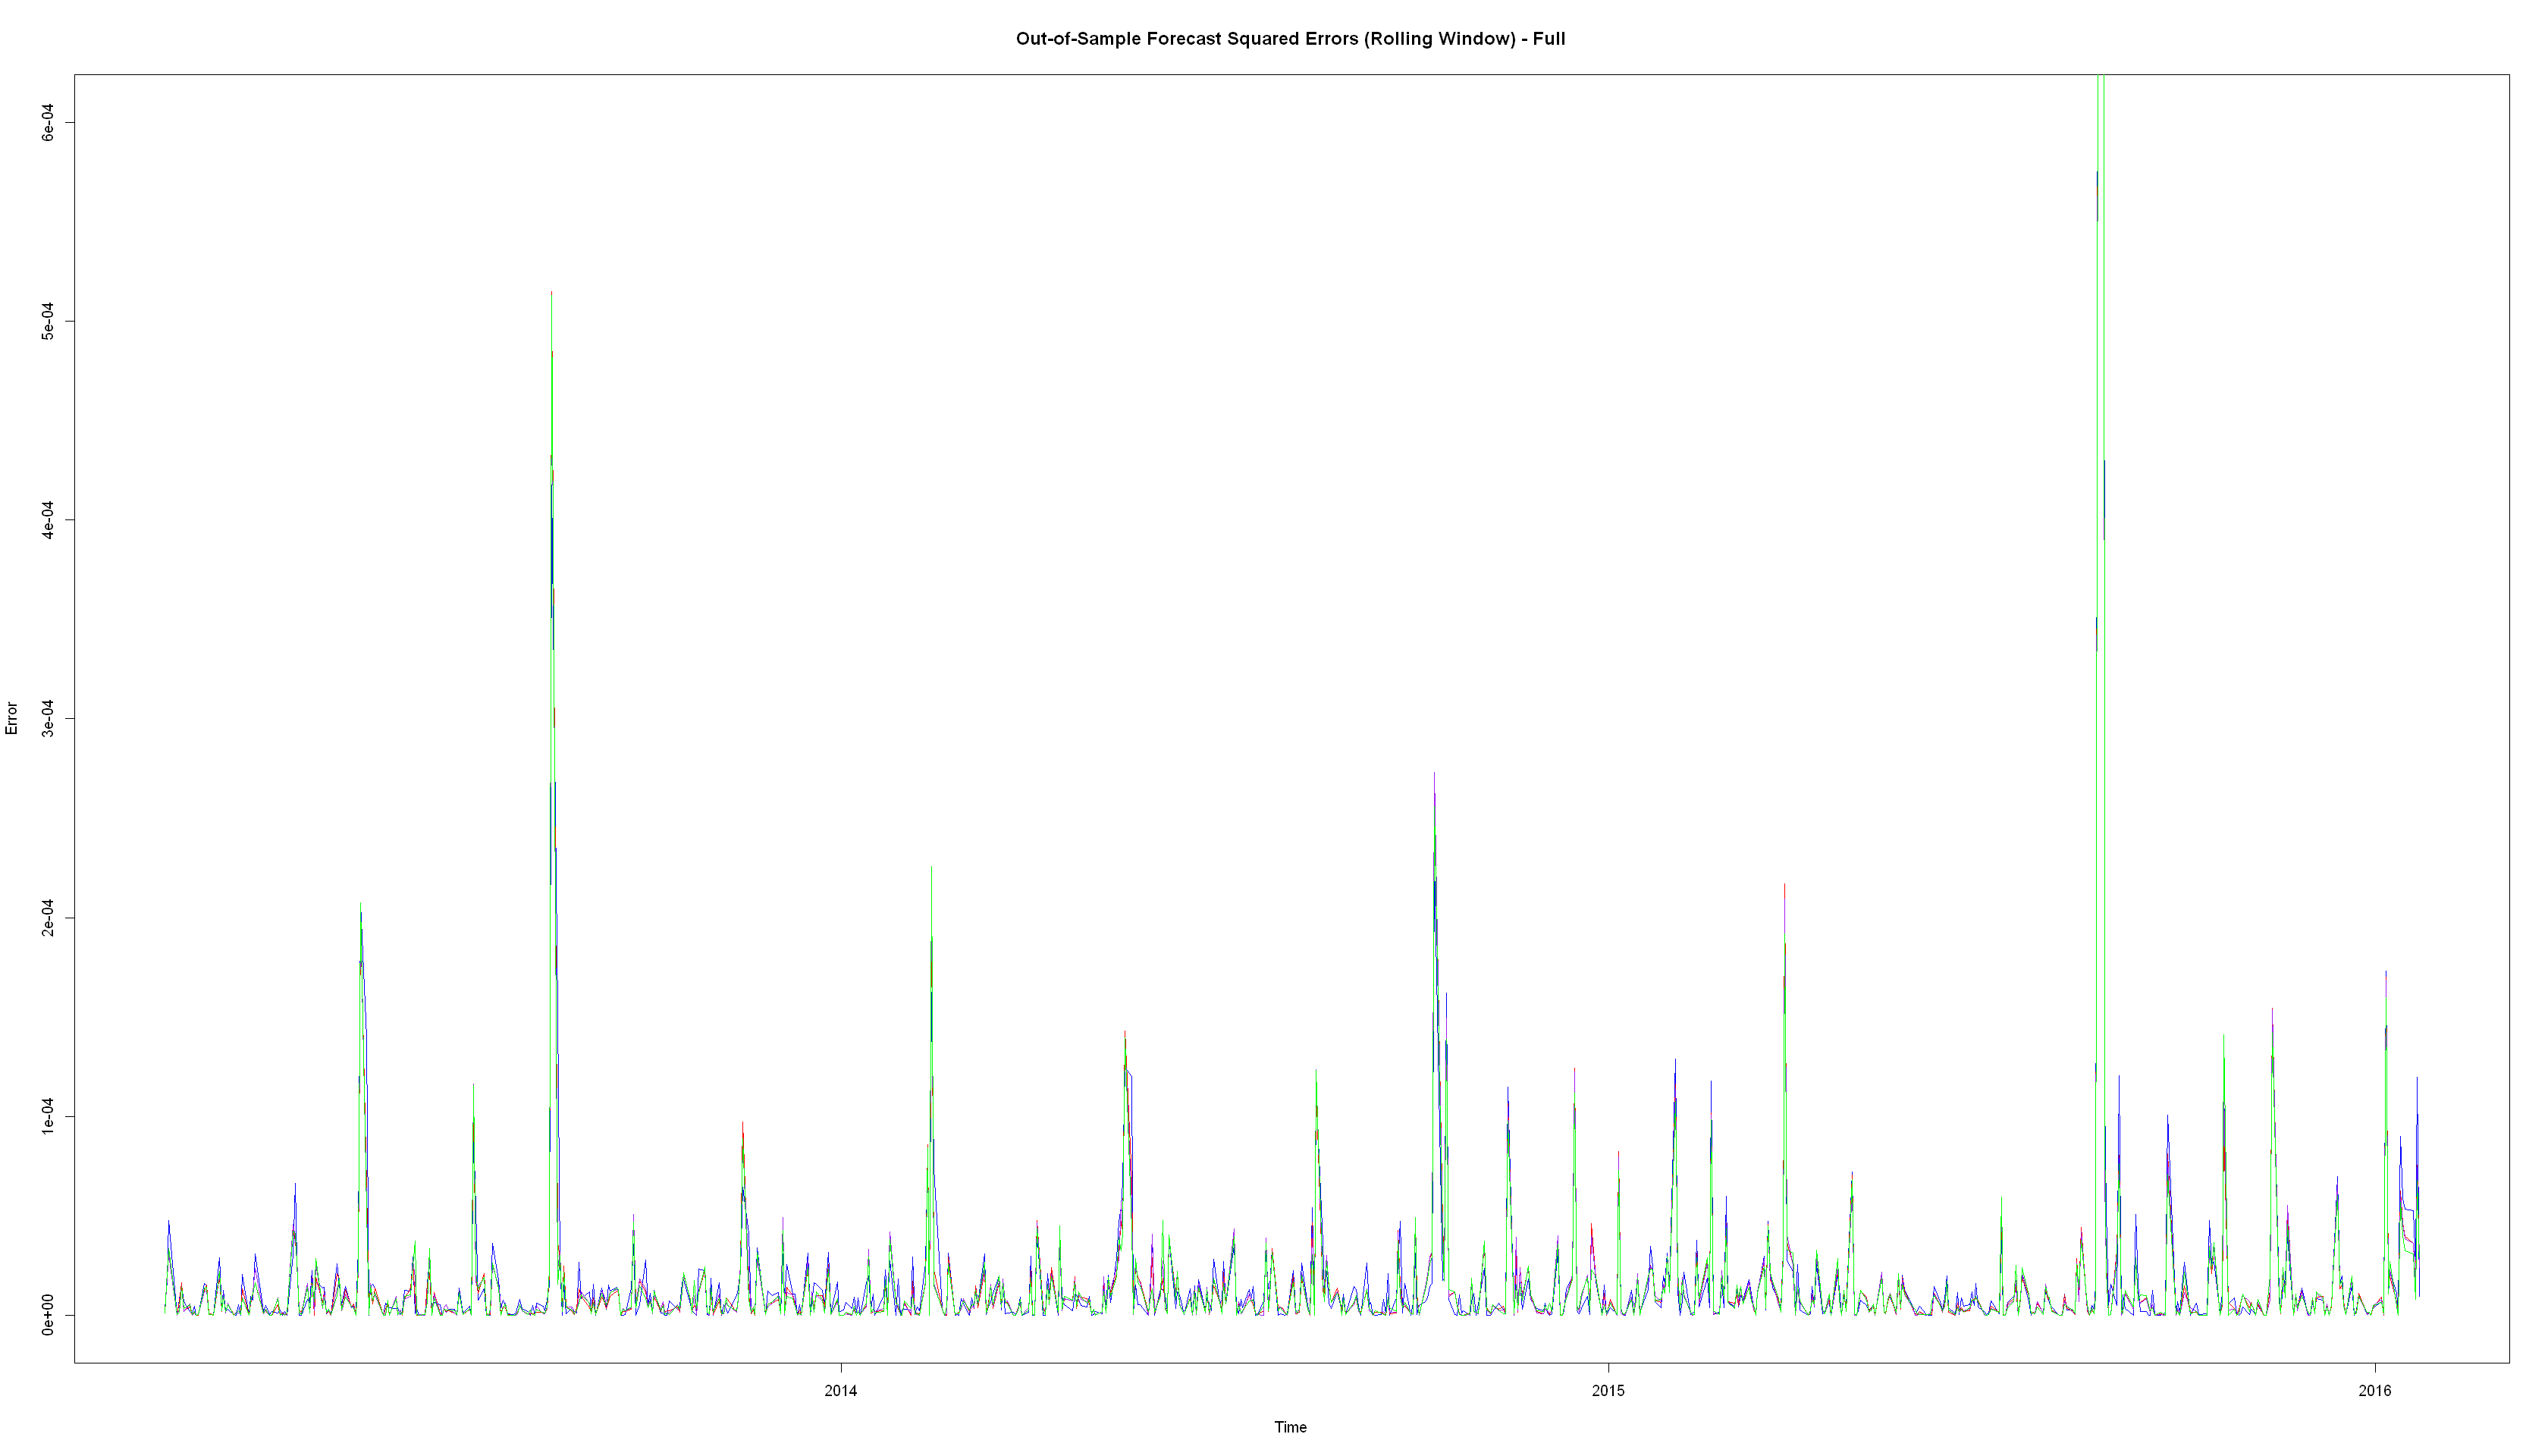

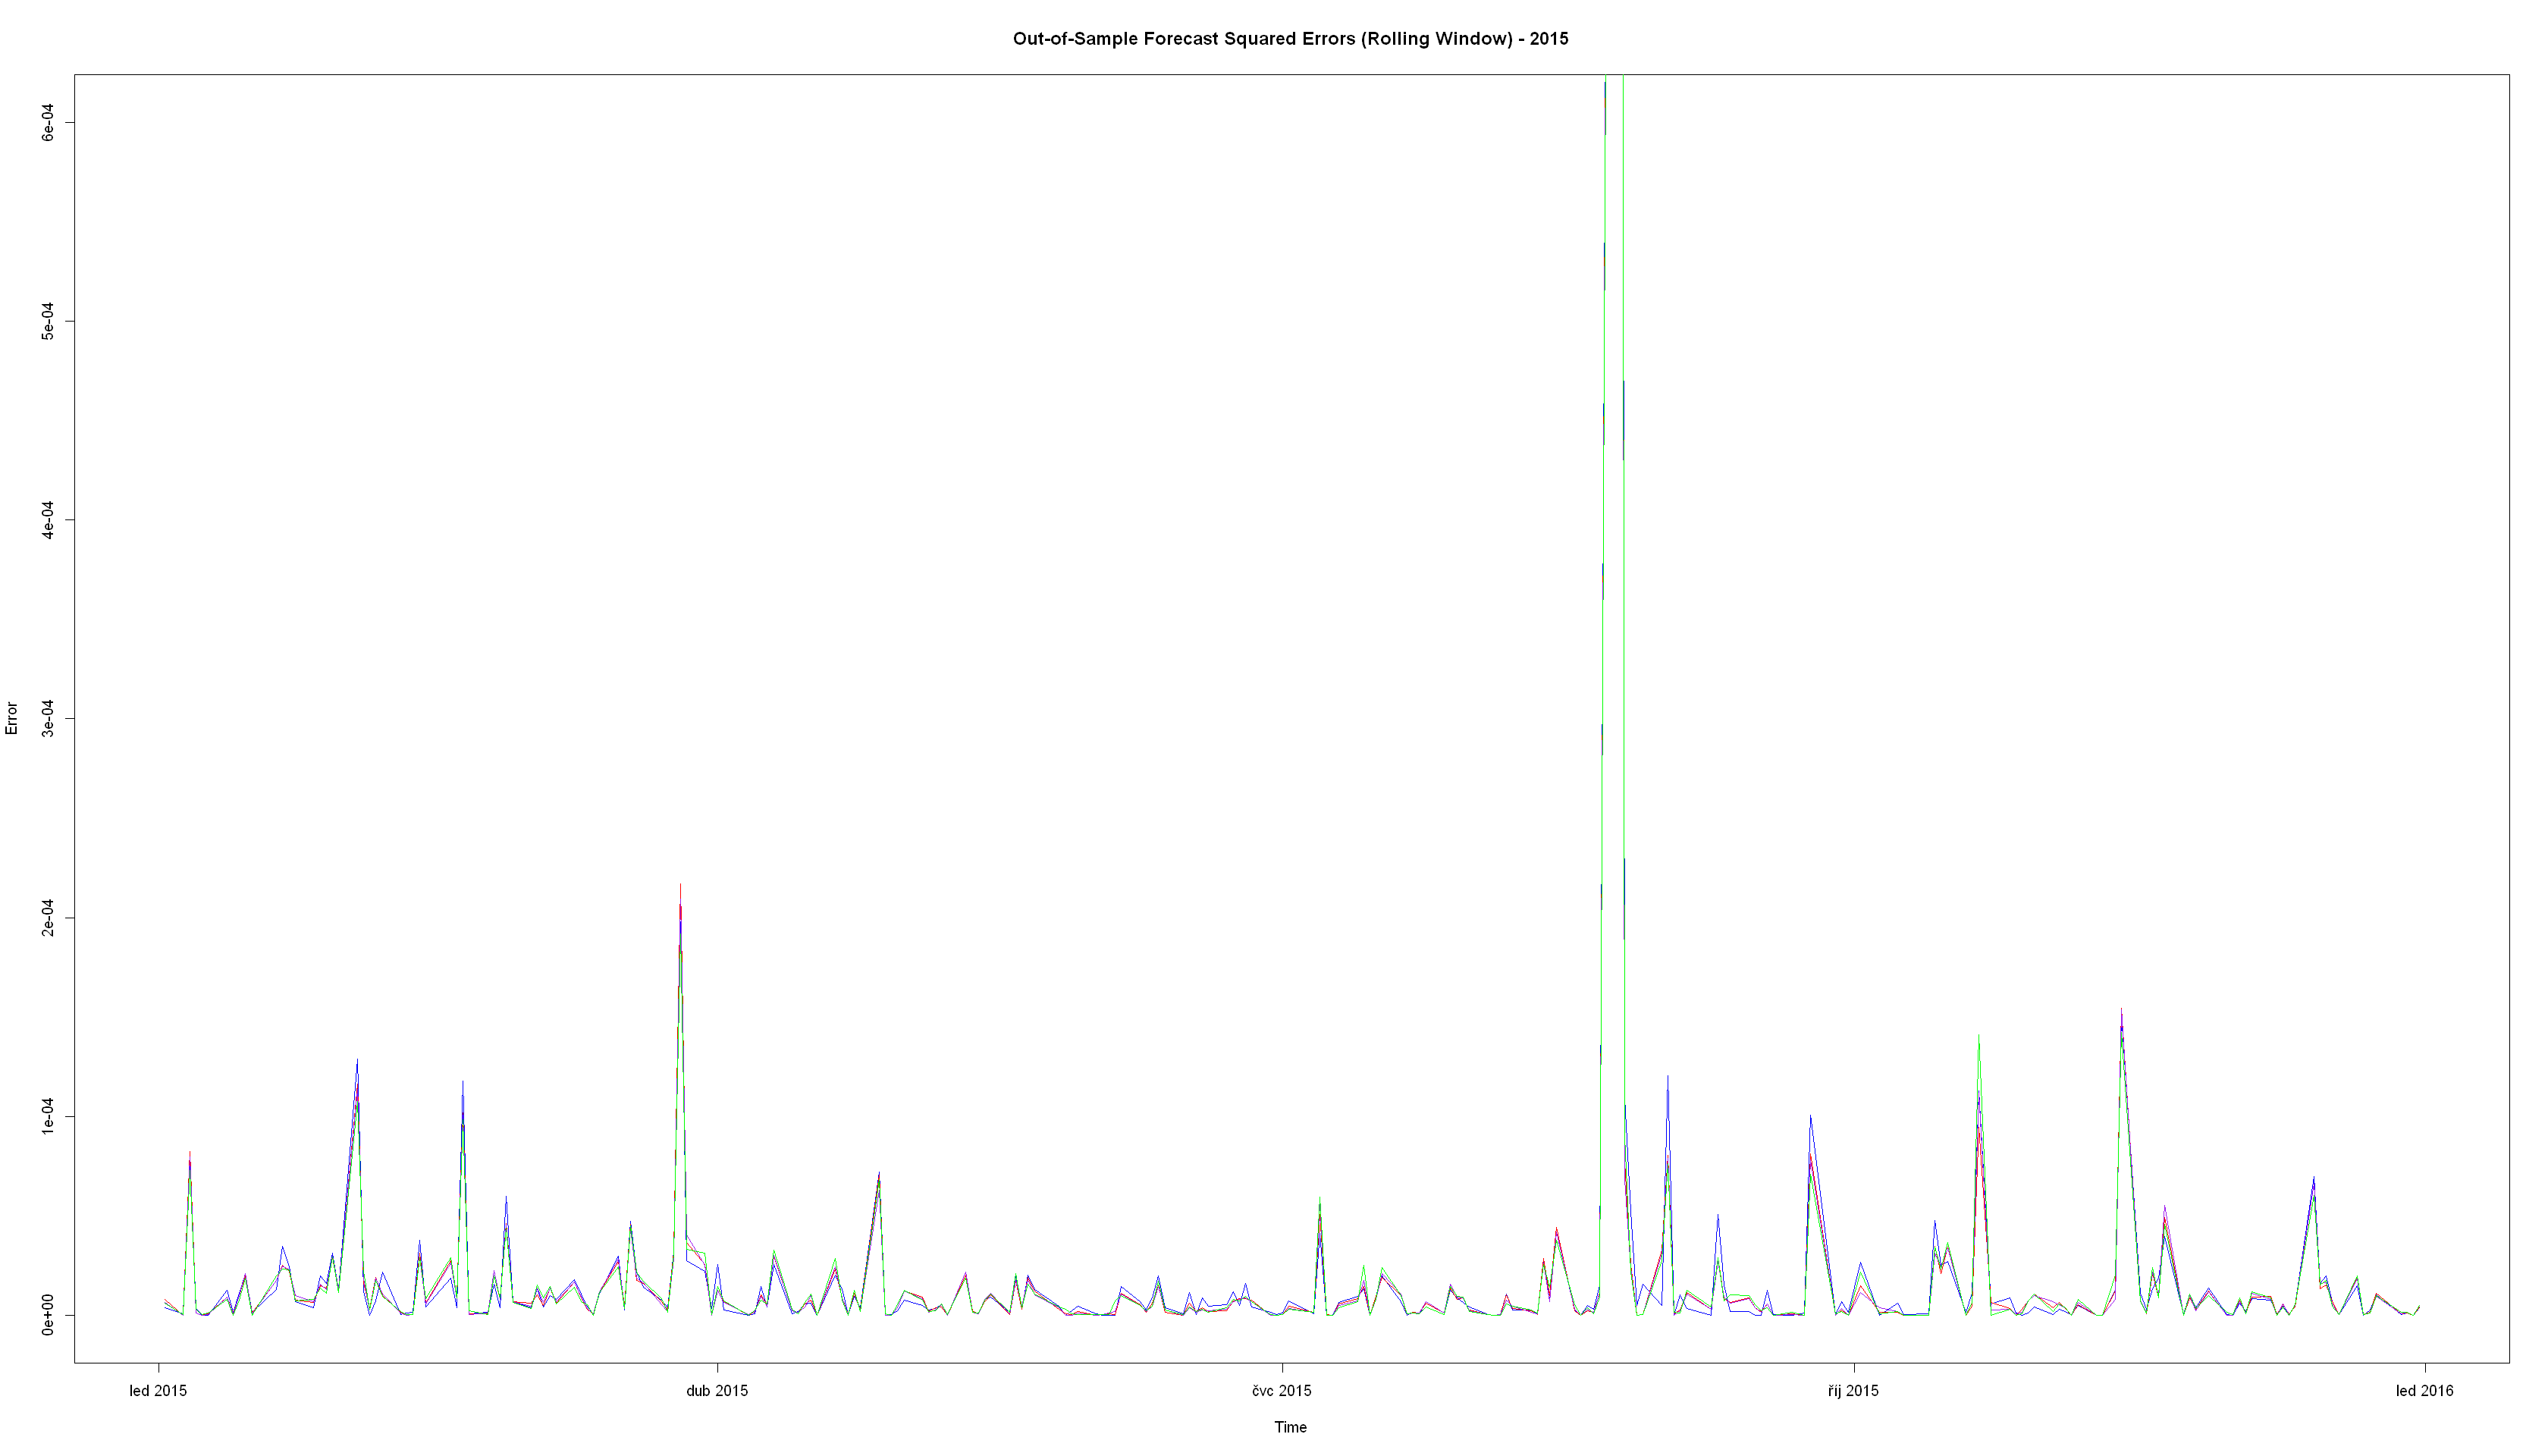

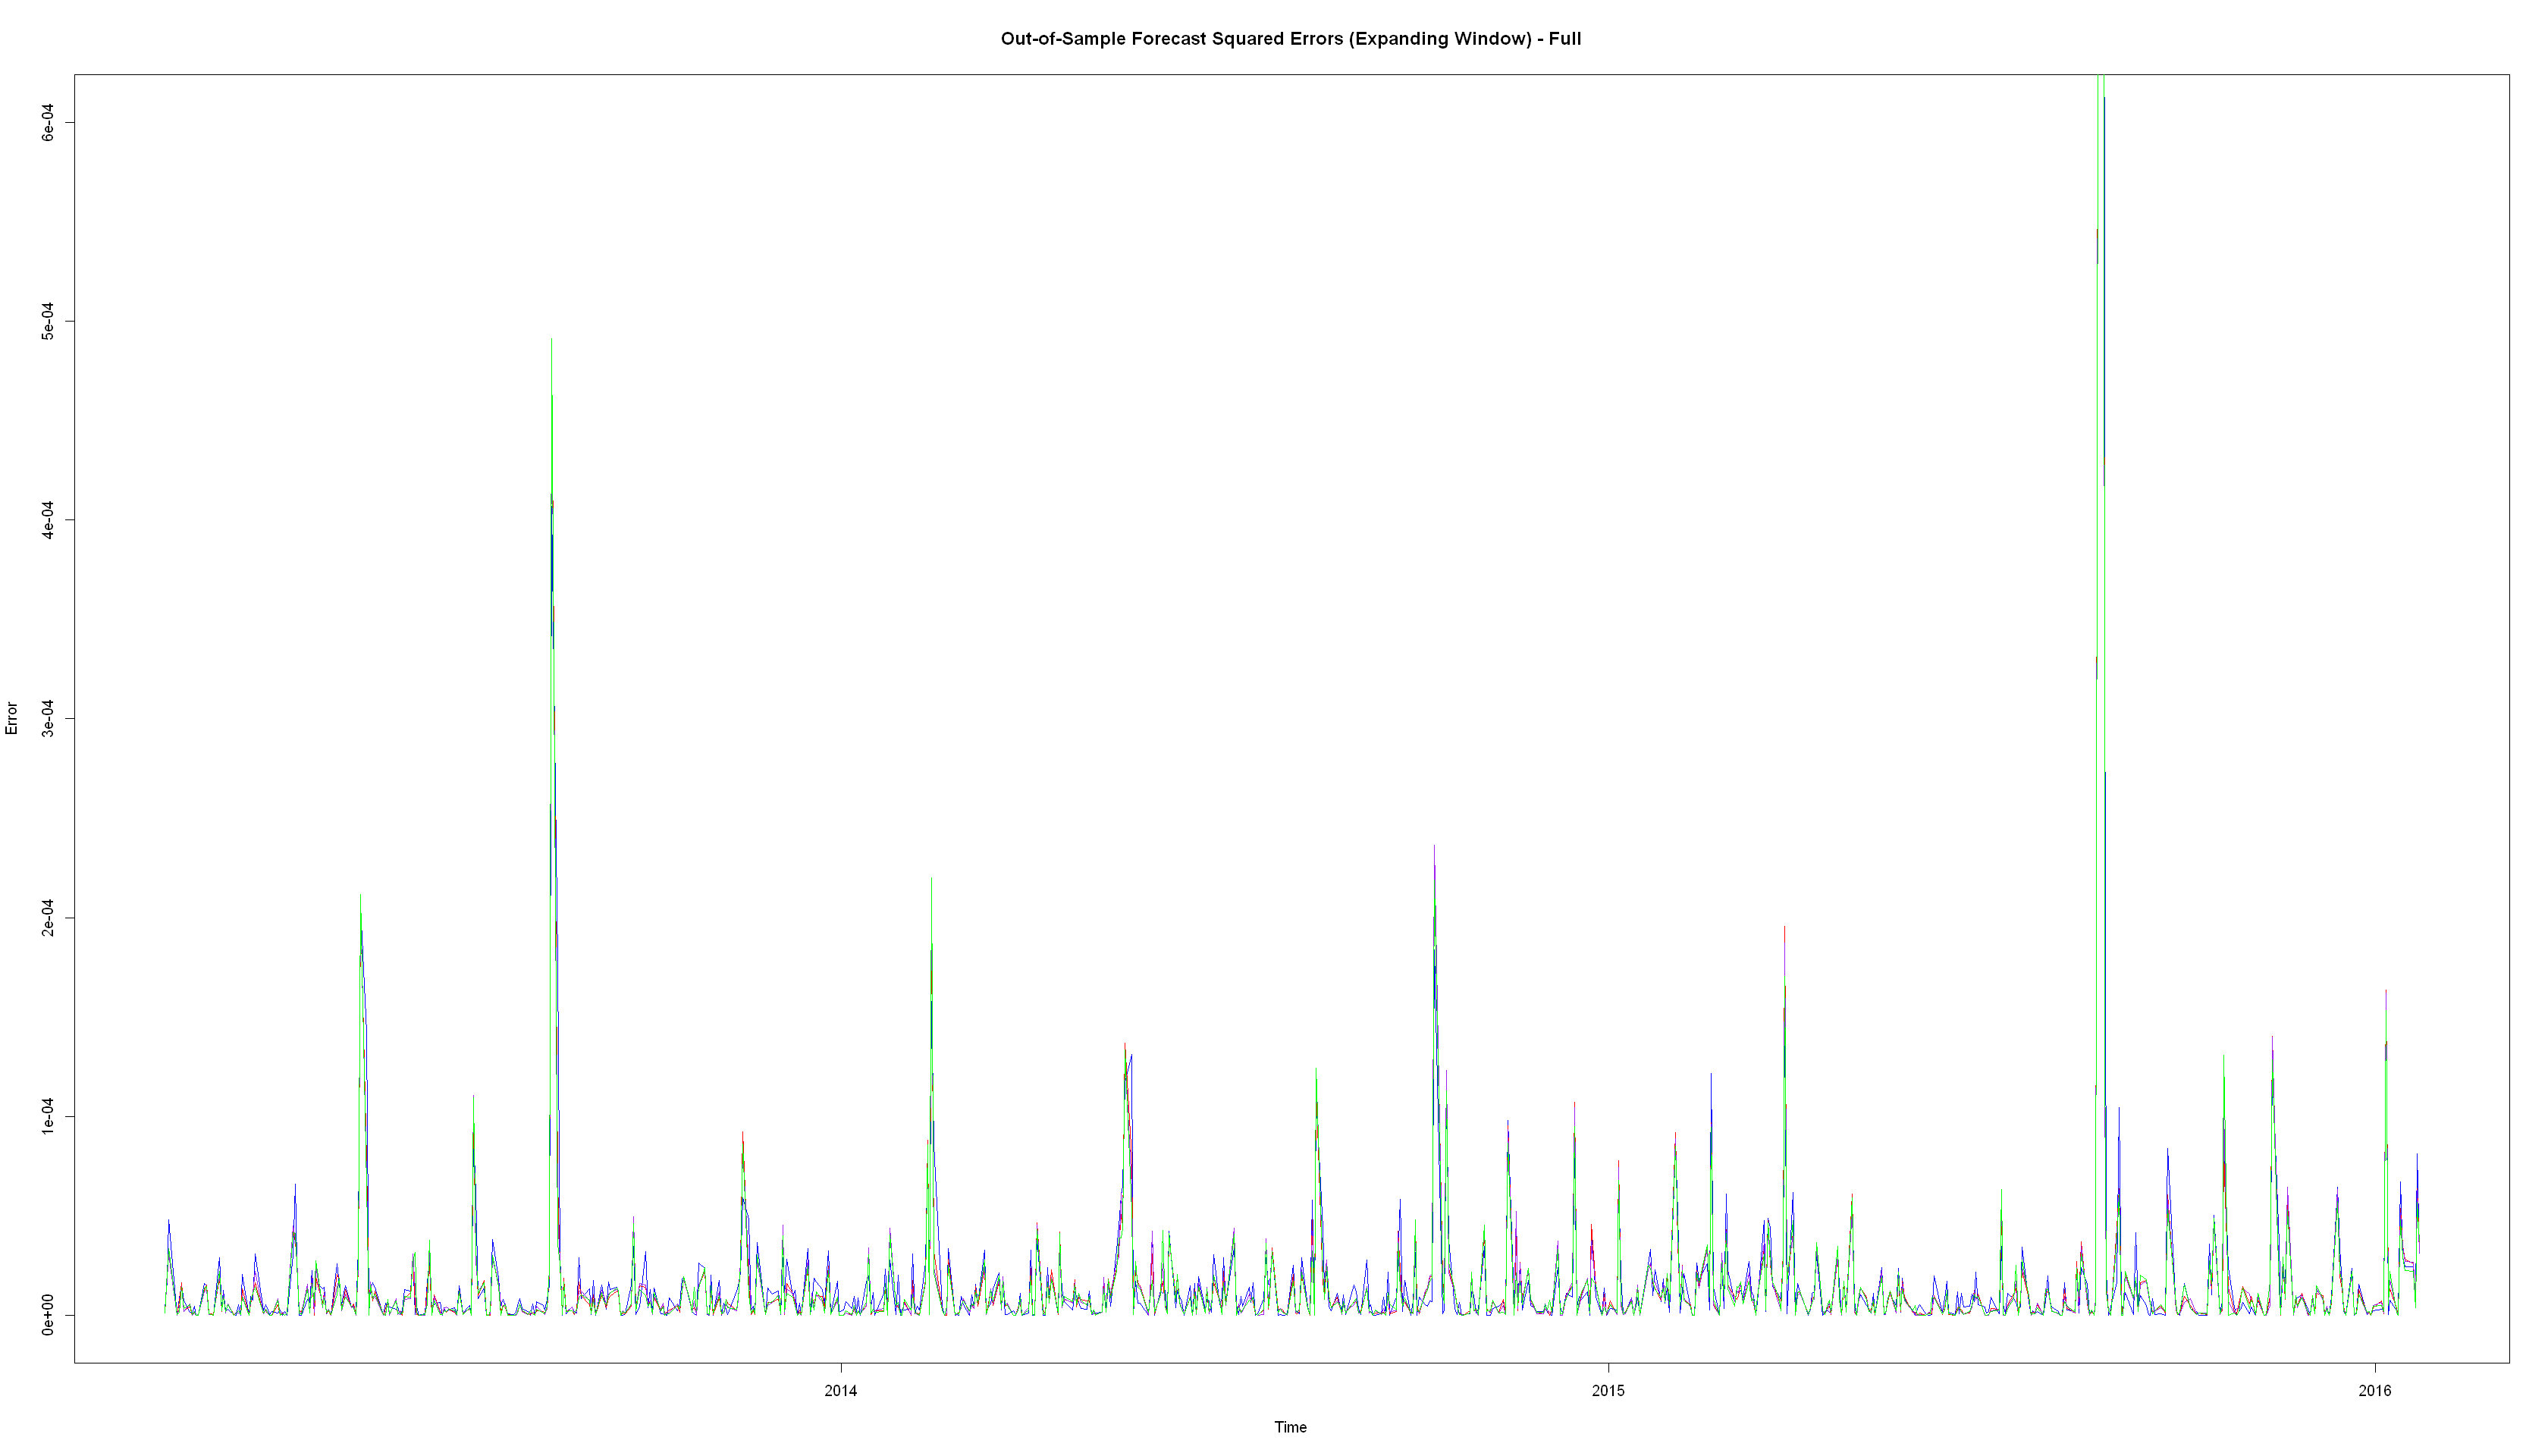

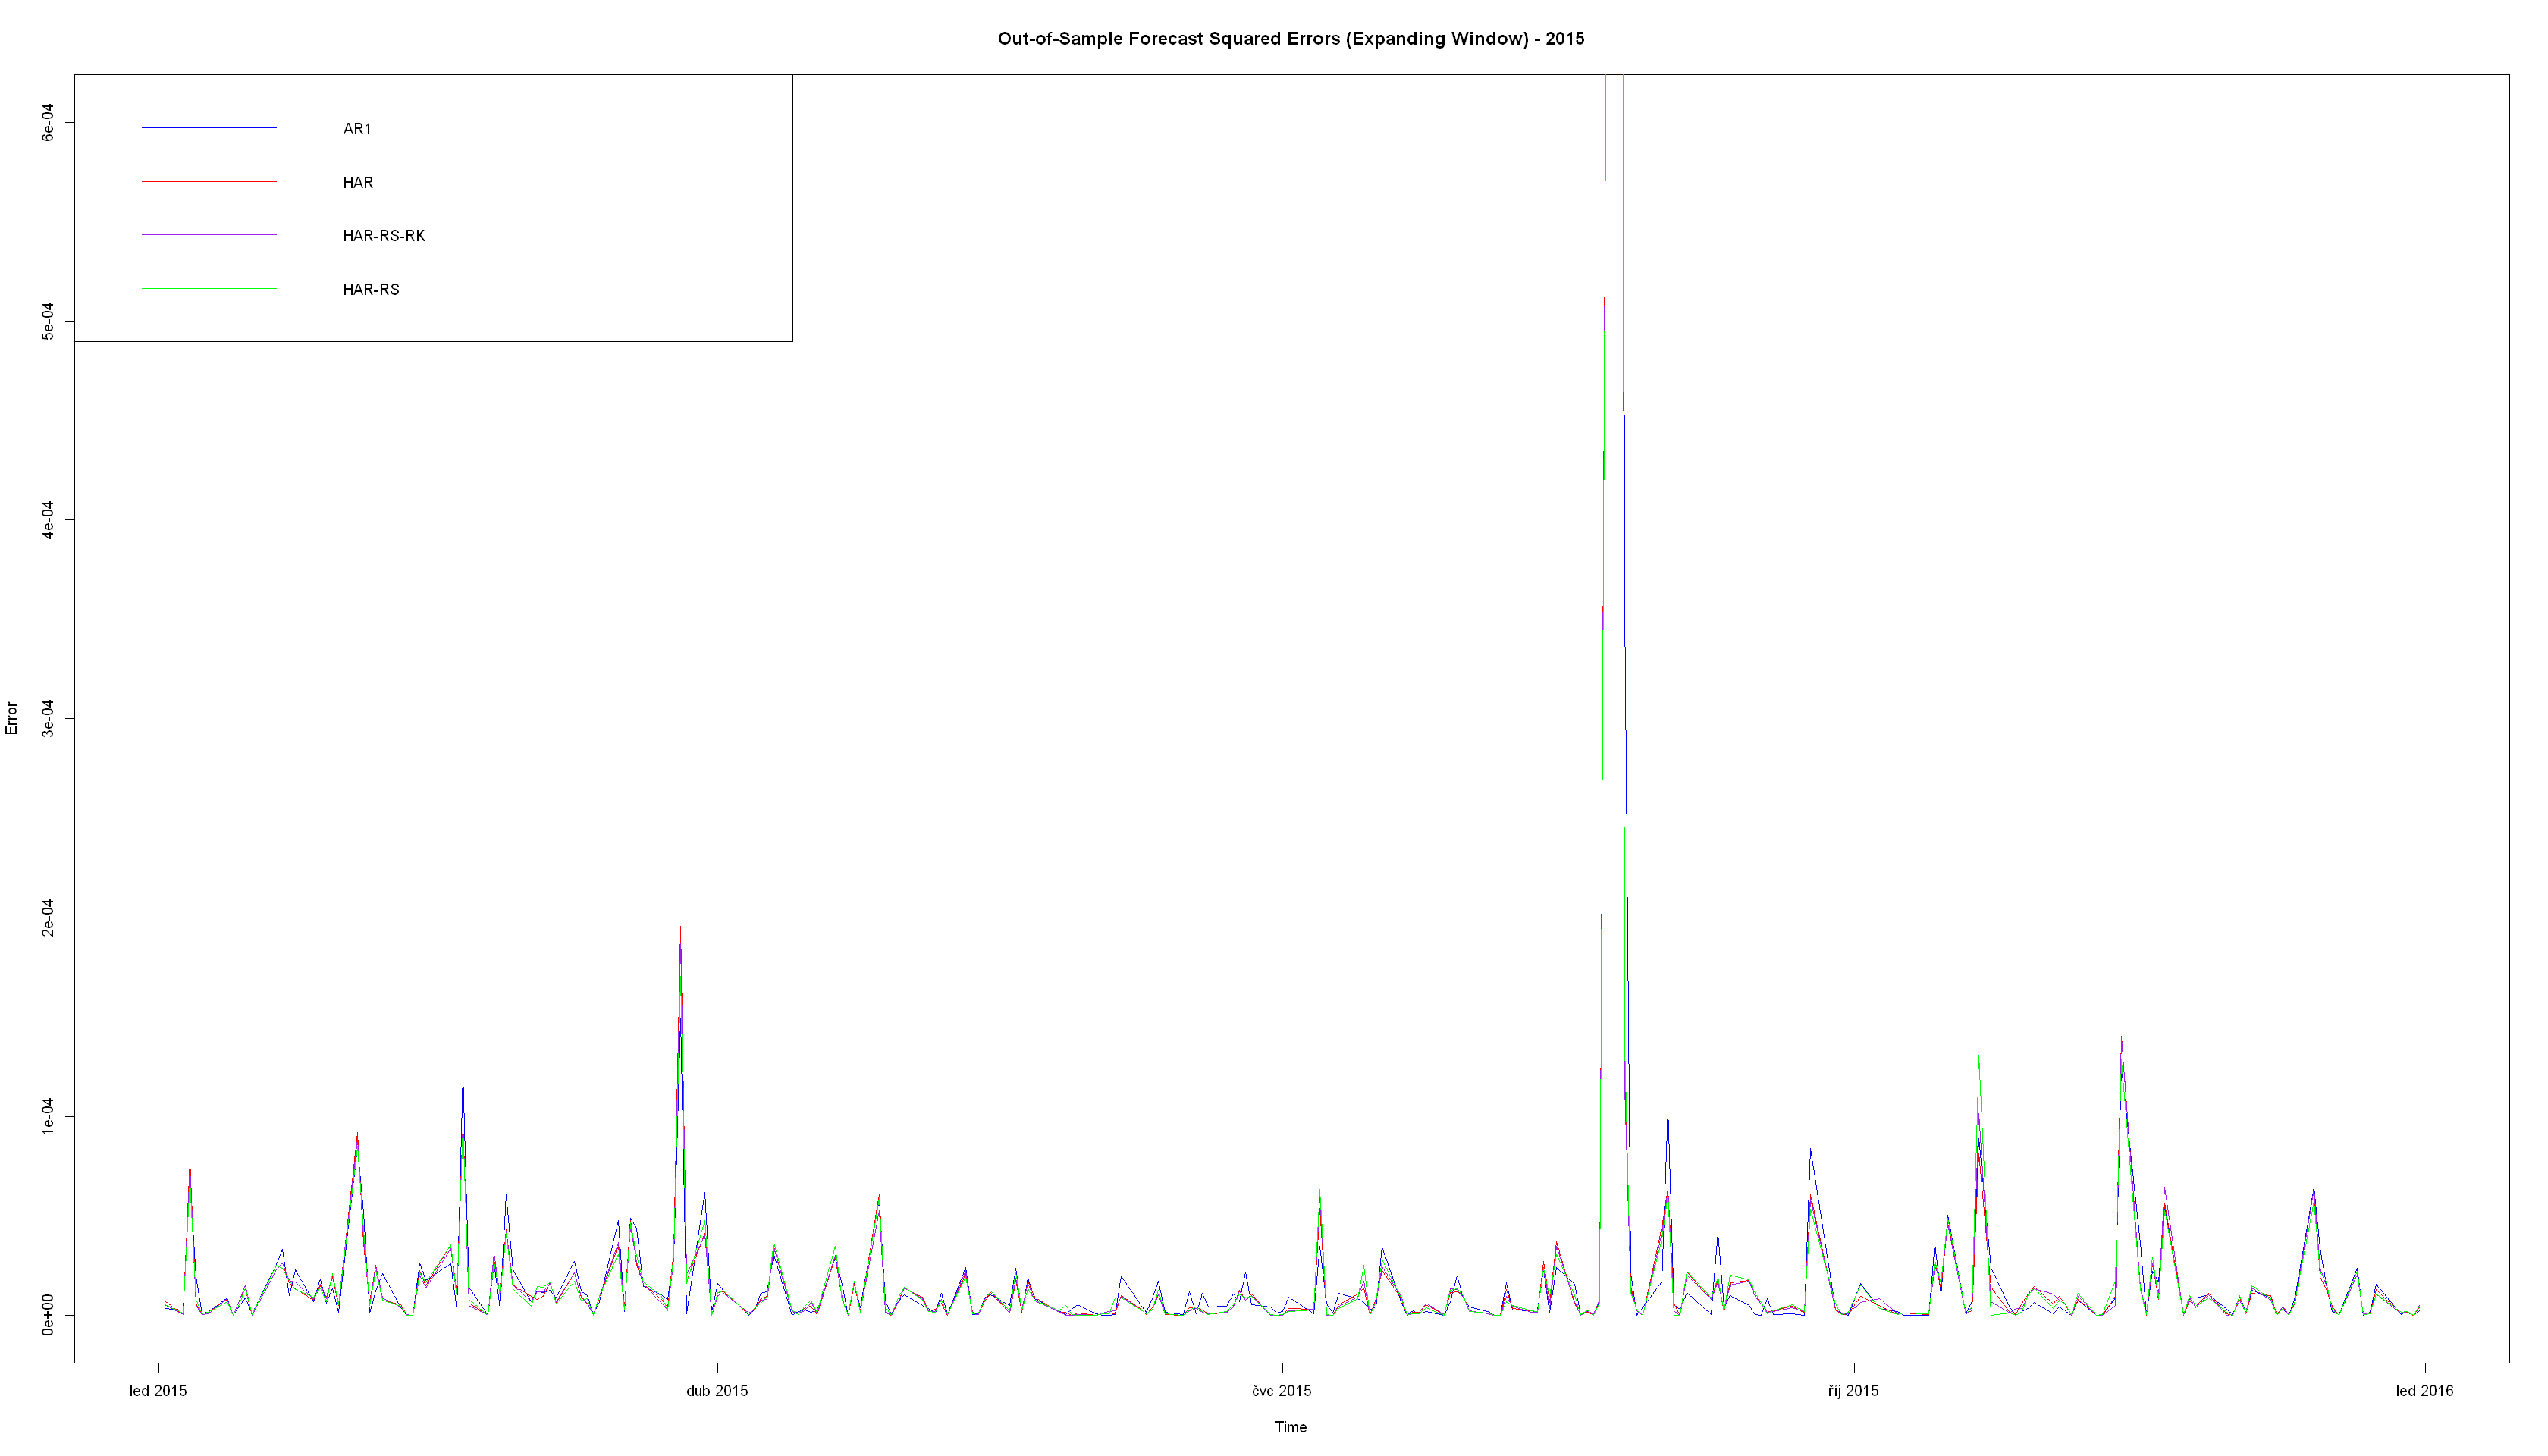

In [41]:
all_errors_roll_2015 <- all_errors_roll["2015"]
all_errors_exp_2015 <- all_errors_exp["2015"]
options(repr.plot.width = 28, repr.plot.height = 16)
# plot.zoo with plot.type="single" elegantly plots all columns at once
zoo::plot.zoo(all_errors_roll^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors (Rolling Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_roll_2015^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors (Rolling Window) - 2015", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors (Expanding Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp_2015^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Squared Errors (Expanding Window) - 2015", 
            ylab = "Error", xlab = "Time")
# Add the legend
legend("topleft", legend = c("AR1", "HAR", "HAR-RS-RK", "HAR-RS"), 
        col = c("blue", "red", "purple", "green"), lty = 1)


#### 3.2.2 GARCH models

In [42]:
# Date the HAR/AR1 forecasts (currently plain numeric) using har_data's index
har_oos_dates <- index(har_data)[(window_len + 1):nrow(har_data)]
mk <- function(v, nm) { x <- xts(v, order.by = har_oos_dates); colnames(x) <- nm; x }

har_fc <- merge(
mk(fcst_ar1_roll,       "AR1_Roll"),  mk(fcst_har_roll,       "HAR_Roll"),
mk(fcst_har_rs_roll,    "HARRS_Roll"),mk(fcst_har_rs_rk_roll, "HARRSRK_Roll"),
mk(fcst_ar1_exp,        "AR1_Exp"),   mk(fcst_har_exp,        "HAR_Exp"),
mk(fcst_har_rs_exp,     "HARRS_Exp"), mk(fcst_har_rs_rk_exp,  "HARRSRK_Exp"))

# GARCH forecasts (already xts, volatility units); relabel to match the scheme
g_sgarch_roll <- f_sgarch_mov; colnames(g_sgarch_roll) <- "sGARCH_Roll"
g_real_roll   <- f_real_mov;   colnames(g_real_roll)   <- "realGARCH_Roll"
g_sgarch_exp  <- f_sgarch_exp; colnames(g_sgarch_exp)  <- "sGARCH_Exp"
g_real_exp    <- f_real_exp;   colnames(g_real_exp)    <- "realGARCH_Exp"

true_rv <- xts(as.numeric(asset_data$RV), order.by = as.Date(index(asset_data)))
colnames(true_rv) <- "True_RV"

# Align everything on the common dates (intersection -> 728 days)
eval_xts <- na.omit(merge(true_rv, har_fc,
                        g_sgarch_roll, g_real_roll, g_sgarch_exp, g_real_exp))
actual  <- as.numeric(eval_xts$True_RV)
fc_cols <- setdiff(colnames(eval_xts), "True_RV")
cat(sprintf("Aligned evaluation sample: %d days, %s to %s\n",
          nrow(eval_xts), start(eval_xts), end(eval_xts)))



Aligned evaluation sample: 728 days, 2013-02-13 to 2016-01-22


In [43]:
loss_tab <- t(sapply(fc_cols, function(cn) {
e <- actual - as.numeric(eval_xts[, cn]); c(MSE = mean(e^2), MAE = mean(abs(e)))
}))
cat("--- OUT-OF-SAMPLE LOSS (common 728-day sample) ---\n")
print(round(loss_tab, 8))

--- OUT-OF-SAMPLE LOSS (common 728-day sample) ---
                     MSE        MAE
AR1_Roll       1.720e-05 0.00289612
HAR_Roll       1.603e-05 0.00276971
HARRS_Roll     1.599e-05 0.00276796
HARRSRK_Roll   1.569e-05 0.00276138
AR1_Exp        1.718e-05 0.00293730
HAR_Exp        1.577e-05 0.00277631
HARRS_Exp      1.571e-05 0.00277204
HARRSRK_Exp    1.543e-05 0.00276319
sGARCH_Roll    2.794e-05 0.00420947
realGARCH_Roll 1.733e-05 0.00303939
sGARCH_Exp     3.026e-05 0.00446380
realGARCH_Exp  1.732e-05 0.00306349


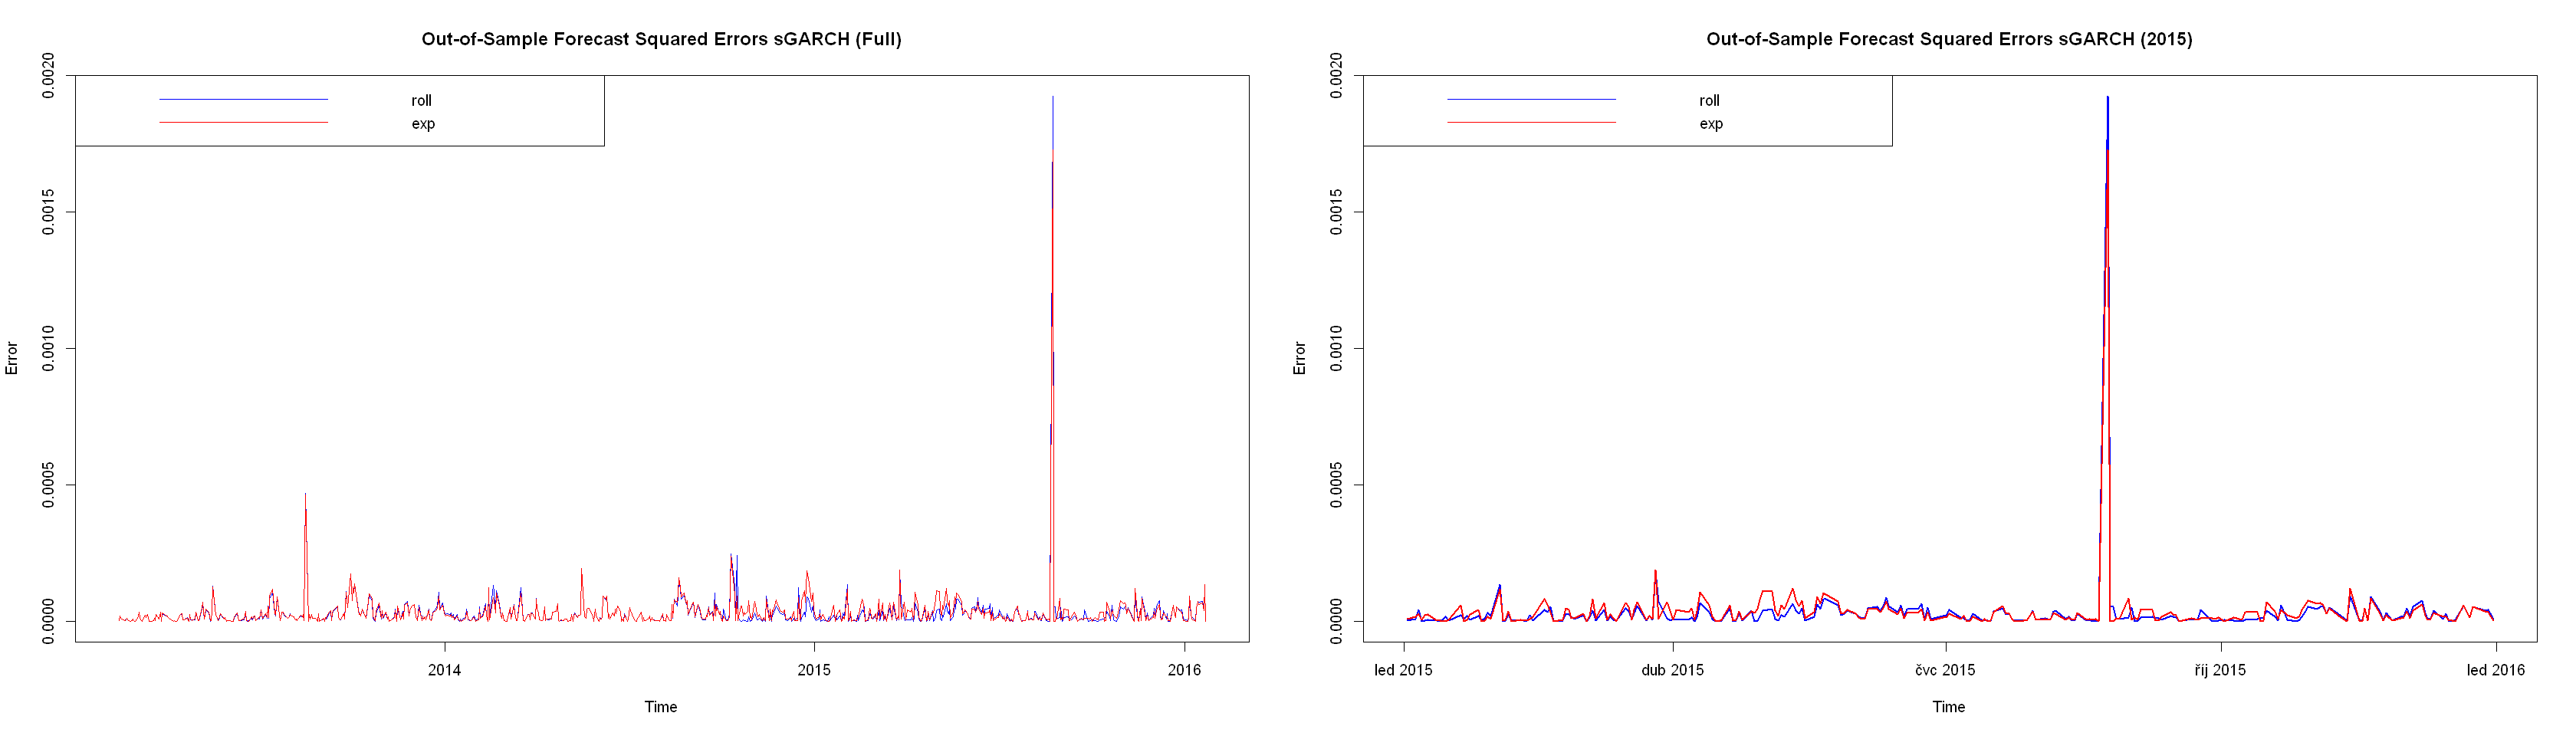

In [53]:
# ---- sGARCH forecast errors (rolling vs expanding) ----
options(repr.plot.width = 28, repr.plot.height = 8)

err_sgarch_roll <- eval_xts$True_RV - eval_xts$sGARCH_Roll
err_sgarch_exp  <- eval_xts$True_RV - eval_xts$sGARCH_Exp
sgarch_errors      <- merge(err_sgarch_roll, err_sgarch_exp)
sgarch_errors_2015 <- sgarch_errors["2015"]

par(mfrow = c(1, 2))
zoo::plot.zoo(sgarch_errors ^ 2, plot.type = "single",
          col = c("blue", "red"), lwd = 1.5,
          main = "Out-of-Sample Forecast Squared Errors sGARCH (Full)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)

zoo::plot.zoo(sgarch_errors_2015 ^ 2, plot.type = "single",
          col = c("blue", "red"), lwd = 2,
          main = "Out-of-Sample Forecast Squared Errors sGARCH (2015)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)
par(mfrow = c(1, 1))

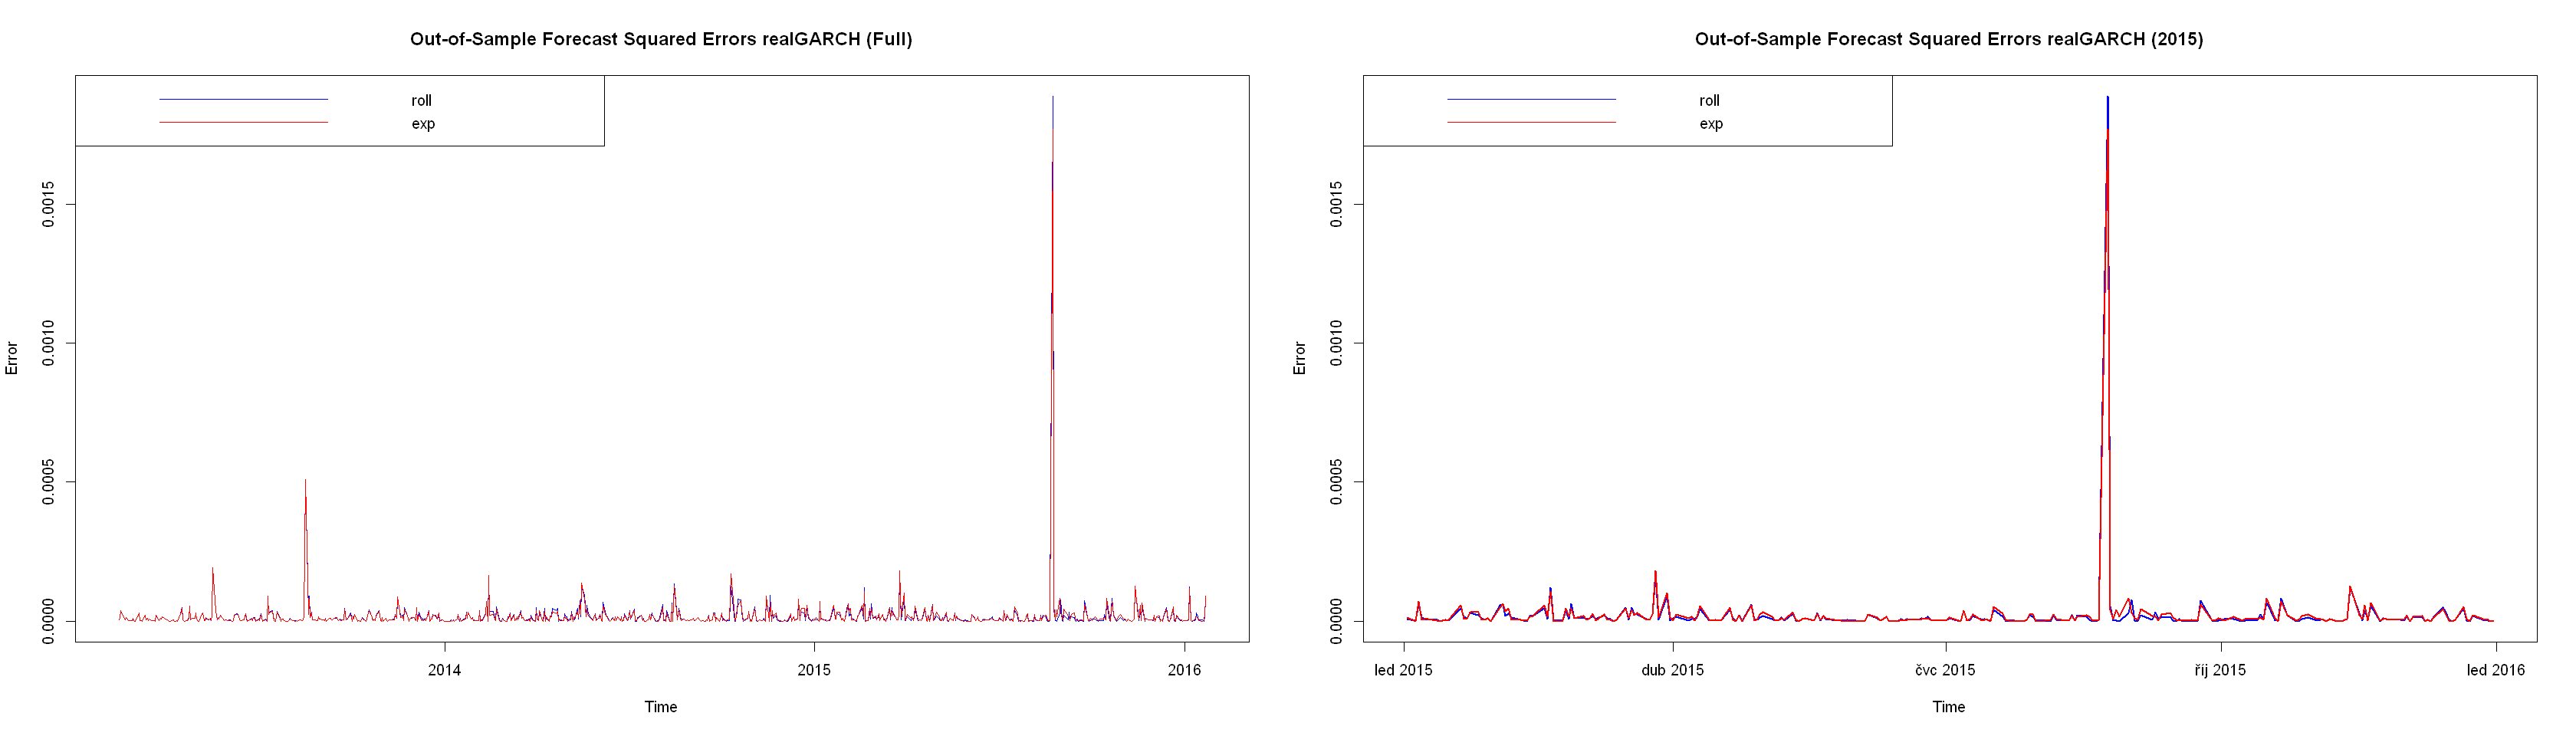

In [54]:
# ---- realGARCH forecast errors (rolling vs expanding) ----
options(repr.plot.width = 28, repr.plot.height = 8)

err_real_roll <- eval_xts$True_RV - eval_xts$realGARCH_Roll
err_real_exp  <- eval_xts$True_RV - eval_xts$realGARCH_Exp
real_errors      <- merge(err_real_roll, err_real_exp)
real_errors_2015 <- real_errors["2015"]

par(mfrow = c(1, 2))
zoo::plot.zoo(real_errors ^ 2, plot.type = "single",
          col = c("blue", "red"), lwd = 1.5,
          main = "Out-of-Sample Forecast Squared Errors realGARCH (Full)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)

zoo::plot.zoo(real_errors_2015 ^ 2, plot.type = "single",
          col = c("blue", "red"), lwd = 2,
          main = "Out-of-Sample Forecast Squared Errors realGARCH (2015)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)
par(mfrow = c(1, 1))

  Visually, the four HAR-family forecasts are almost indistinguishable. Their lines overlap
  throughout both the rolling and expanding panels, and they follow the level and persistence
  of realized volatility closely. The simple AR(1) is slightly more erratic, overshooting some
  of the smaller fluctuations, which is why it again comes out as the weakest of the four. The
  differences within the HAR family, by contrast, are marginal. HAR is yielding basically same results as the HAR with realized skewness and the third model with added kurtosis is slightly improved when checking the error measures. The two GARCH models behave
  quite differently from each other: realGARCH tracks realized volatility almost as closely as
  the HAR models, whereas the plain sGARCH is visibly smoother and, in the calm stretch of
  2015, flattens out entirely. Its ARCH coefficient collapses to near zero, so the forecast
  reverts to a constant long-run level and stops reacting to the data.
  
  Turning to the loss functions, within the HAR family the expanding window yields slightly
  lower MSE for every model, while MAE shows the opposite pattern. This discrepancy is itself
  informative: MSE squares the errors and is therefore dominated by a handful of large misses,
  whereas MAE weights them linearly. The differences are nonetheless tiny and the errors are
  extremely small, so it is inconclusive which scheme is preferable. The best model overall is
  the HAR specification augmented with realized skewness and kurtosis (HAR-RS-RK), though only
  by a hair.
  
  The contrast between the two model classes is sharper. The plain sGARCH is clearly the
  weakest model of all: its MSE is nearly double that of the best HAR model and its MAE about
  60% higher, reflecting both its inability to use the realized measure and the flat-forecast
  episode noted above. Adding the realized measure transforms this: realGARCH improves
  dramatically over sGARCH, reaching an MSE on par with the AR(1) benchmark (and far below
  sGARCH), though it remains marginally behind on MAE and, on both metrics, still short of the
  HAR regressions. The estimation scheme also matters more for the GARCH models: sGARCH is
  noticeably better under the rolling window than the expanding one (the opposite of the HAR
  pattern) while realGARCH is essentially unaffected by the choice. Overall, the
  regression-based HAR family dominates. Feeding realized volatility directly into the variance
  equation (realGARCH) closes most of the GARCH gap, but it does not overtake the HAR models,
  and the returns-only sGARCH trails everything.
  
  What stands out most in every error plot is a single dominant spike in the second half of
  2015. It corresponds to a large jump in realized volatility, visible as the peak to
  roughly 0.06 in the forecast-vs-RV figure, that none of the models, HAR or GARCH,
  anticipated. The one-step-ahead forecasts all top out far below the realized peak. This one
  event produces a squared error an order of magnitude larger than a typical day and accounts
  for a sizeable share of the total MSE, which is also why the squared-error view is so
  dominated by it. It illustrates a general limitation shared by all the models: they capture
  the persistent, slowly evolving component of volatility well, but cannot predict sudden
  jumps. Outside such episodes the forecasts hug the realized series tightly.

  MSE / MAE table

  | Model      | MSE Roll (×10⁻⁵) | MAE Roll (×10⁻³) | MSE Exp (×10⁻⁵) | MAE Exp (×10⁻³) |
  |------------|:----------------:|:----------------:|:---------------:|:---------------:|
  | AR(1)      | 1.720            | 2.896            | 1.718           | 2.937           |
  | HAR        | 1.603            | 2.770            | 1.577           | 2.776           |
  | HAR-RS     | 1.599            | 2.768            | 1.571           | 2.772           |
  | HAR-RS-RK  | **1.569**        | **2.761**        | **1.543**       | **2.763**       |
  | sGARCH     | 2.795            | 4.210            | 3.026           | 4.464           |
  | realGARCH  | 1.733            | 3.039            | 1.732           | 3.063           |
  
  *Out-of-sample loss on the common 728-day sample. MSE in units of 10⁻⁵, MAE in units of
  10⁻³; bold marks the lowest value in each metric (HAR-RS-RK).*

### 3.3 Statistical tests

In [46]:
# MSE-loss Diebold-Mariano (power = 2, h = 1). p < 0.05 => accuracy differs.
dm_p <- function(a, b) {
e1 <- actual - as.numeric(eval_xts[, a])
e2 <- actual - as.numeric(eval_xts[, b])
o <- tryCatch(dm.test(e1, e2, alternative = "two.sided", h = 1, power = 2), error = function(e) NULL)
if (is.null(o)) NA else round(o$p.value, 4)
}

cat("--- DIEBOLD-MARIANO p-values vs HAR baseline (MSE loss) ---\n\n")
cat("Rolling:\n")
for (m in c("AR1_Roll","HARRS_Roll","HARRSRK_Roll","sGARCH_Roll","realGARCH_Roll")) {
cat(sprintf("  HAR_Roll vs %-15s p = %s\n", m, dm_p("HAR_Roll", m)))
}
cat("\nExpanding:\n")
for (m in c("AR1_Exp","HARRS_Exp","HARRSRK_Exp","sGARCH_Exp","realGARCH_Exp")) {
cat(sprintf("  HAR_Exp  vs %-15s p = %s\n", m, dm_p("HAR_Exp", m)))
}

--- DIEBOLD-MARIANO p-values vs HAR baseline (MSE loss) ---

Rolling:
  HAR_Roll vs AR1_Roll        p = 0.0014
  HAR_Roll vs HARRS_Roll      p = 0.6472
  HAR_Roll vs HARRSRK_Roll    p = 0.0557
  HAR_Roll vs sGARCH_Roll     p = 0
  HAR_Roll vs realGARCH_Roll  p = 0.0195

Expanding:
  HAR_Exp  vs AR1_Exp         p = 0.0035
  HAR_Exp  vs HARRS_Exp       p = 0.5103
  HAR_Exp  vs HARRSRK_Exp     p = 0.0617
  HAR_Exp  vs sGARCH_Exp      p = 0
  HAR_Exp  vs realGARCH_Exp   p = 0.002


In [47]:
# Regress actual on each forecast: RV_t = a + b*forecast_t + u_t
# Joint H0: a = 0 AND b = 1 (forecast is unbiased/efficient). p < 0.05 => reject.
mz_tab <- t(sapply(fc_cols, function(cn) {
f <- as.numeric(eval_xts[, cn]); m <- lm(actual ~ f)
b <- coef(m); V <- vcov(m); d <- c(b[1] - 0, b[2] - 1)
Fstat <- as.numeric(t(d) %*% solve(V) %*% d) / 2
c(a = b[1], b = b[2], R2 = summary(m)$r.squared,
  F = Fstat, p_joint = pf(Fstat, 2, length(actual) - 2, lower.tail = FALSE))
}))
cat("--- MINCER-ZARNOWITZ (joint H0: a=0, b=1) ---\n")
print(round(mz_tab, 5))

--- MINCER-ZARNOWITZ (joint H0: a=0, b=1) ---
               a.(Intercept)     b.f      R2         F p_joint
AR1_Roll             0.00161 0.87489 0.18195   2.10107 0.12307
HAR_Roll             0.00029 0.98576 0.23359   0.21155 0.80938
HARRS_Roll           0.00037 0.98136 0.23578   0.32907 0.71970
HARRSRK_Roll         0.00033 0.98358 0.24997   0.28786 0.74995
AR1_Exp              0.00285 0.76165 0.21630  17.59654 0.00000
HAR_Exp              0.00145 0.88751 0.25029   2.26483 0.10458
HARRS_Exp            0.00148 0.88756 0.25303   2.15443 0.11671
HARRSRK_Exp          0.00141 0.89304 0.26584   2.04083 0.13067
sGARCH_Roll          0.00716 0.40810 0.02263 133.38229 0.00000
realGARCH_Roll       0.00255 0.76059 0.24440  35.22386 0.00000
sGARCH_Exp           0.00482 0.53251 0.06204 197.23176 0.00000
realGARCH_Exp        0.00250 0.75970 0.25322  39.66122 0.00000


**Diebold–Mariano test:** The DM test asks whether the differences in MSE we observed above
are statistically significant or just sampling noise. We compare every model against the HAR
baseline (a p-value below 0.05 means the accuracy differs significantly, and the loss table
tells us in which direction). HAR is statistically indistinguishable from its richer versions
HAR-RS (p ≈ 0.65 / 0.51) and, more marginally, HAR-RS-RK (p ≈ 0.056 / 0.062), so the extra
realized regressors do not deliver significantly better forecasts. Against every other model,
however, HAR is significantly superior: it beats AR(1) (p ≈ 0.001 / 0.004), sGARCH (p ≈ 0) and
even realGARCH (p ≈ 0.020 / 0.002) under both schemes (even though their raw MSEs looked almost identical).

**Mincer–Zarnowitz regression:** This regression evaluates each forecast on its own by
regressing realized volatility on the forecast ($RV_t = a + b\cdot \widehat{RV}_t + u_t.$). An unbiased, efficient forecast has intercept
a = 0 and slope b = 1 (joint H₀), so a p-value below 0.05 flags a biased or mis-scaled
forecast. The HAR family passes: rolling HAR is near-perfectly calibrated (b ≈ 0.98, p ≈ 0.81),
and the expanding versions are also not rejected at 5%. realGARCH is the instructive case, as its
R² (≈ 0.25) matches the HAR models, so it is genuinely informative, yet its slope (b ≈ 0.76)
is well below one and the joint test rejects it. We thus conclude that the forecast carries the right signal but is
mis-scaled and would perhaps need a simple linear recalibration. sGARCH fails on every count, with a
slope near 0.4-0.5 and an R² of only 0.02-0.06, both biased and almost uninformative.

## 4. Summary

We compared six volatility models: AR(1)-RV, HAR, HAR-RS, HAR-RS-RK, sGARCH and realGARCH.
Both in-sample and in a one-step-ahead out-of-sample exercise under rolling and expanding
windows of length 750, evaluated on a common sample.

The **HAR family is the clear winner**. The three HAR specifications produce almost identical,
well-fitting forecasts that track realized volatility closely. They attain the lowest MSE and
MAE, are statistically more accurate than AR(1) and both GARCH models (Diebold–Mariano), and
are the only forecasts the Mincer–Zarnowitz regression cannot reject as unbiased and efficient
(slope ≈ 1). Because enriching HAR with realized skewness and kurtosis yields no statistically
significant gain, eventhough the gain is noticeable in the error measures, the parsimonious **HAR**  model seems to be the best choice, because it matches the more
elaborate variants while remaining the simplest.

Among the variance-equation models, incorporating the realized measure matters enormously.
**realGARCH** explains as much of the variation in realized volatility as the HAR models
(comparable R²) and vastly outperforms the standard **sGARCH**, but it remains biased
(MZ slope ≈ 0.76) and significantly less accurate than HAR. It carries the right signal yet is
mis-scaled. The plain sGARCH is the weakest model throughout: biased, almost uninformative,
and prone to flattening out when its ARCH effect collapses in calm periods (as in 2015).

The choice between **rolling and expanding** windows makes little difference, as losses are nearly
identical across schemes, with only a marginal calibration edge for the rolling HAR. Finally, a
limitation common to all models is their inability to anticipate sudden jumps. The large
volatility spike in the second half of 2015 was missed by every specification and dominates the
squared-error profile, reflecting that these models capture the persistent component of
volatility well but not abrupt shocks. Overall, the **rolling HAR** emerges as the best
all-round performer.

